# Does a protein's *chemistry* explain how confident AlphaFold is?

### An AP Biology / AP Chemistry investigation using real structural data

In 2021, an AI system called **AlphaFold** did something biologists had been trying to do
for fifty years: it learned to predict a protein's three-dimensional shape from nothing but
its amino acid sequence. Predictions for essentially every known protein are now free to
download.

Here's the part that makes it interesting for us. AlphaFold doesn't just hand you a shape —
it also tells you **how sure it is about every single amino acid**, on a scale from 0 to 100.
That score is called **pLDDT**. Some residues get a 98. Some get a 33. In the same protein.

So: **why?** What makes AlphaFold confident about one amino acid and unsure about the one
twelve positions later?

This notebook tests one specific idea:

> **Hypothesis.** A residue's *chemistry* — whether its side chain is nonpolar, polar,
> acidic, or basic — is related to how confidently AlphaFold can place it.

We'll find out that the answer is **yes, but not for the reason you'd first guess** — and
chasing down that "but" is where the real science happens.

No prior statistics required. Every statistical idea — standard deviation, confidence
interval, *p*-value, correlation — is explained from scratch as we need it.

---

## Where we're going

| Section | Question we're asking | New statistical tool |
|---|---|---|
| 1 | What does AlphaFold actually give us? | — |
| 2 | What are the 20 amino acids, chemically? | — |
| 3 | What is our protein made of? | Describing a distribution |
| 4 | Does confidence differ by side-chain class? | Confidence intervals, *t*-test, effect size |
| 5 | Can we compare all five classes at once? | One-way ANOVA |
| 6 | What does this look like in 3D? | — |
| 7 | Are nonpolar residues really buried? | Chi-square test |
| 8 | How strong is the relationship? | Regression, *r* and *r²* |
| 9 | Wait — is something else causing this? | Confounding variables |
| 10 | What did we actually learn? | Limitations |

Our main subject is **human lysozyme**, the enzyme in your tears and saliva that kills
bacteria by cutting open their cell walls. It's small (148 amino acids), extremely
well-studied, and completely folded — which makes it a clean place to start.

---

## Setup

We need five tools:

| Library | What we use it for |
|---|---|
| `requests` | downloading real data from the AlphaFold database over the internet |
| `numpy` | fast math on arrays of numbers |
| `pandas` | spreadsheet-like tables (`DataFrame`s) |
| `matplotlib` | every chart in this notebook |
| `scipy.stats` | the statistical tests |

### One important habit: cache your data

This notebook downloads data from live scientific databases. Those databases get updated,
go down for maintenance, and occasionally change their formats. If we re-downloaded
everything on every run, our numbers could silently change from one day to the next — and
in science, **a result you can't reproduce isn't really a result.**

So the `fetch_cached()` function below saves every download to a `data/` folder the first
time, then reads from that folder afterward. Two details worth noticing:

- `resp.raise_for_status()` makes the code **crash loudly** if a download fails. That sounds
  bad, but the alternative is worse: silently continuing with missing data and reporting
  confident conclusions built on nothing.
- The cached files get committed alongside this notebook, so anyone who downloads this
  repository gets the exact numbers you see here.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


def fetch_cached(url, filename, as_json=True):
    # Download `url` once, cache it in data/<filename>, and reuse it on later runs.
    # Raises on any failed download rather than quietly returning empty data.
    path = DATA_DIR / filename
    if path.exists():
        text = path.read_text(encoding="utf-8")
        source = "cache"
    else:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()          # fail loudly, never silently
        text = resp.text
        path.write_text(text, encoding="utf-8")
        source = "downloaded"
    print(f"  {filename:32s} ({source}, {len(text)/1000:.0f} KB)")
    return json.loads(text) if as_json else text


print("Setup complete.")

Setup complete.


---

# 1. What does AlphaFold actually give us?

Let's meet our protein.

**Human lysozyme** is an enzyme found in tears, saliva, and mucus. It's part of your innate
immune system: it attacks bacteria by hydrolyzing the β(1→4) glycosidic bonds in
peptidoglycan, the mesh that gives a bacterial cell wall its strength. Cut enough of those
bonds and the bacterium bursts from its own internal osmotic pressure.

It is 148 amino acids long — small enough to reason about, big enough to have a real folded
core. Its UniProt accession number (a unique ID for a protein, like an ISBN for a book) is
**P61626**.

We ask the AlphaFold database for three things:

1. **The entry record** — metadata about the prediction
2. **The pLDDT scores** — one confidence number per amino acid
3. **The PDB file** — the actual 3D coordinates of every atom

In [2]:
LYSOZYME = "P61626"

print("Fetching human lysozyme:")
entry = fetch_cached(f"https://alphafold.ebi.ac.uk/api/prediction/{LYSOZYME}", "lysozyme_entry.json")[0]
plddt_doc = fetch_cached(entry["plddtDocUrl"], "lysozyme_plddt.json")
pdb_text = fetch_cached(entry["pdbUrl"], "lysozyme.pdb", as_json=False)

sequence = entry["sequence"]
scores = np.array(plddt_doc["confidenceScore"])

# Sanity check: the sequence and the score list must describe the same protein.
# Silently mismatched lengths would quietly corrupt everything downstream.
assert len(sequence) == len(scores), f"length mismatch: {len(sequence)} vs {len(scores)}"

lyso = pd.DataFrame({
    "position": np.arange(1, len(sequence) + 1),
    "aa": list(sequence),
    "pLDDT": scores,
})

print()
print("Protein:        ", entry["uniprotDescription"])
print("Gene:           ", entry["gene"])
print("Length:         ", len(sequence), "amino acids")
print("First 30 residues:", sequence[:30], "...")
print()
print(f"Mean pLDDT:      {lyso['pLDDT'].mean():.2f}")
print(f"Lowest pLDDT:    {lyso['pLDDT'].min():.2f}  (at position {lyso.loc[lyso['pLDDT'].idxmin(), 'position']})")
print(f"Highest pLDDT:   {lyso['pLDDT'].max():.2f}  (at position {lyso.loc[lyso['pLDDT'].idxmax(), 'position']})")

lyso.head()

Fetching human lysozyme:
  lysozyme_entry.json              (cache, 2 KB)
  lysozyme_plddt.json              (cache, 2 KB)
  lysozyme.pdb                     (cache, 99 KB)

Protein:         Lysozyme C
Gene:            LYZ
Length:          148 amino acids
First 30 residues: MKALIVLGLVLLSVTVQGKVFERCELARTL ...

Mean pLDDT:      94.07
Lowest pLDDT:    45.06  (at position 2)
Highest pLDDT:   98.94  (at position 27)


,position,aa,pLDDT
0,1,M,46.31
1,2,K,45.06
2,3,A,53.47
3,4,L,58.12
4,5,I,58.97


### Reading a pLDDT score

pLDDT stands for *predicted Local Distance Difference Test*. Ignore the name; what matters
is the interpretation. It is AlphaFold's own answer to the question *"if someone determined
this structure experimentally, how close would my prediction be, right here at this
residue?"*

The AlphaFold team defines four standard bands:

| pLDDT | Meaning | Official color |
|---|---|---|
| **> 90** | Very high — expect near-experimental accuracy | dark blue |
| **70 – 90** | Confident — the backbone is probably right | light blue |
| **50 – 70** | Low — treat with caution | yellow |
| **< 50** | Very low — often means the region has *no single stable shape at all* | orange |

That last row is the surprising one, and it will matter a lot later. A very low score is
usually not AlphaFold failing. It's AlphaFold correctly reporting that there is nothing
fixed to predict.

Let's look at every residue of lysozyme at once, two ways.

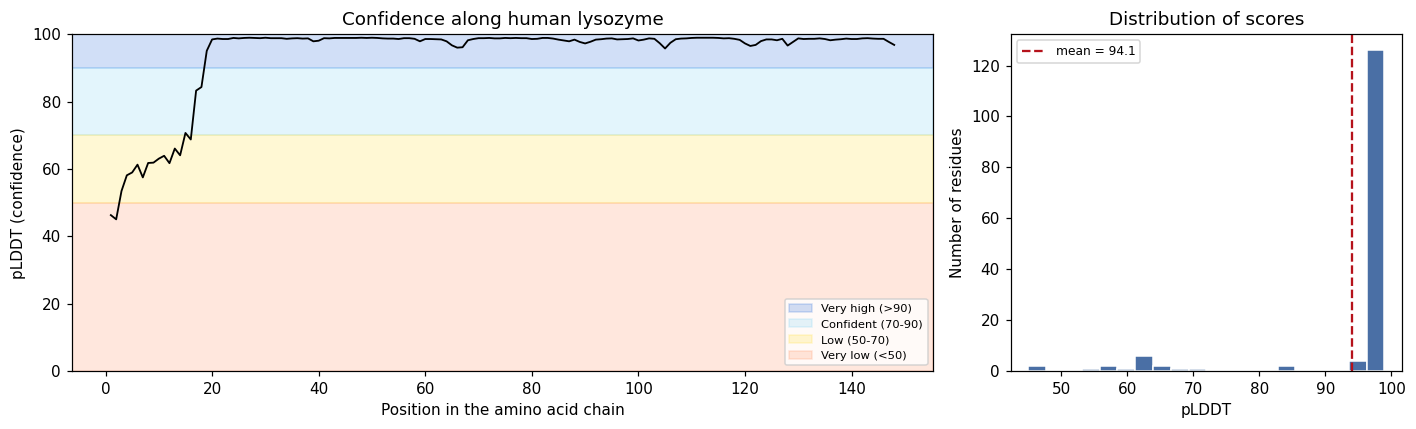

pLDDT
Very high (>90)      130
Confident (70-90)      3
Low (50-70)           13
Very low (<50)         2


In [3]:
BANDS = [(90, 100, "#0053D6", "Very high (>90)"),
         (70, 90, "#65CBF3", "Confident (70-90)"),
         (50, 70, "#FFDB13", "Low (50-70)"),
         (0, 50, "#FF7D45", "Very low (<50)")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2.2, 1]})

# Left: confidence along the amino acid chain
for low, high, color, label in BANDS:
    ax1.axhspan(low, high, color=color, alpha=0.18, label=label)
ax1.plot(lyso["position"], lyso["pLDDT"], color="black", linewidth=1.2)
ax1.set_xlabel("Position in the amino acid chain")
ax1.set_ylabel("pLDDT (confidence)")
ax1.set_title("Confidence along human lysozyme")
ax1.set_ylim(0, 100)
ax1.legend(loc="lower right", fontsize=7.5)

# Right: the same numbers as a distribution
ax2.hist(lyso["pLDDT"], bins=20, color="#4A6FA5", edgecolor="white")
ax2.axvline(lyso["pLDDT"].mean(), color="#B5121B", linestyle="--", linewidth=1.5,
            label=f"mean = {lyso['pLDDT'].mean():.1f}")
ax2.set_xlabel("pLDDT")
ax2.set_ylabel("Number of residues")
ax2.set_title("Distribution of scores")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

band_counts = pd.cut(lyso["pLDDT"], bins=[0, 50, 70, 90, 100],
                     labels=["Very low (<50)", "Low (50-70)", "Confident (70-90)", "Very high (>90)"])
print(band_counts.value_counts().reindex(
    ["Very high (>90)", "Confident (70-90)", "Low (50-70)", "Very low (<50)"]).to_string())

### What we're looking at

The left panel shows the score at every one of the 148 positions, and it has an obvious
shape: one low region at the very start, then a wall of dark blue for the entire rest of the
chain. 130 of the 148 residues score above 90.

**That low stretch at positions 1–16 is not a mistake.** Look at the sequence we printed
above: `MKALIVLGLVLLSVTVQG...`. That's lysozyme's **signal peptide**, and it's a beautiful
piece of AP Bio hiding in our data.

Lysozyme is a *secreted* protein — it has to get out of the cell to reach bacteria. Proteins
headed for secretion are translated by ribosomes that dock onto the rough endoplasmic
reticulum, guided there by exactly this kind of N-terminal signal sequence. Once the chain is
threaded into the ER, an enzyme called signal peptidase **cuts the signal peptide off**. So
the lysozyme actually working in your tears is residues **19–148**. Residues 1–18 are a
shipping label that gets torn off on delivery.

Why does AlphaFold score it so low? Because AlphaFold is predicting this chain floating on
its own, and on its own a signal peptide genuinely has no single stable shape — it only folds
into a helix once it's embedded in a membrane. A low pLDDT here is AlphaFold being *right*.

One detail to file away: that signal peptide is aggressively **hydrophobic** — leucine,
valine, isoleucine, alanine, over and over. Nonpolar residues, with *low* confidence scores.
If you expected "hydrophobic = buried = confident," this stretch does the exact opposite.
Hold onto that. It comes back in section 9.

The right panel shows the same 148 numbers as a **distribution** — how many residues fall in
each score range. Notice it's badly *lopsided*: a tall spike near 95–99 and a thin tail
trailing to the left. This shape matters for the statistics we do later, because several
common tests quietly assume data is symmetric and bell-shaped. Ours isn't, and we'll deal
with that honestly rather than ignore it.

So we have a protein AlphaFold is confident about, with some real variation to explain.
Now — what is it *made of*?

---

# 2. The 20 amino acids, chemically

Every protein on Earth is built from the same 20 amino acids. They share an identical
backbone — an amino group, a central α-carbon, and a carboxyl group — and differ **only** in
the side chain (the "R group") hanging off that α-carbon.

That side chain is the whole story. It determines whether a residue wants to be near water
or hide from it, whether it carries a charge, whether it can form hydrogen bonds, and how
much space it takes up.

### Grouping by chemistry

We'll sort the 20 into five classes:

| Class | Members | Chemistry |
|---|---|---|
| **Hydrophobic** | A, V, L, I, M, F, W | Nonpolar side chains — hydrocarbons and aromatic rings. No significant dipole, so no favorable interaction with water. |
| **Polar** | S, T, N, Q, Y | Uncharged but contain –OH, –NH₂, or C=O groups that **hydrogen bond** with water. |
| **Acidic** | D, E | Carboxylic acid side chains, pKa ≈ 4. At pH 7 they are **deprotonated → negatively charged**. |
| **Basic** | K, R, H | Amine/guanidinium side chains. Lys and Arg have high pKa and are **protonated → positively charged** at pH 7. |
| **Special** | G, P, C | Structural oddballs. Gly is tiny and ultra-flexible; Pro kinks the backbone; Cys forms disulfide bridges. |

### Two AP Chemistry ideas doing real work here

**1. pKa tells you the charge at a given pH.** Aspartate's side chain has a pKa near 3.9.
Blood is around pH 7.4 — over three pH units *above* that pKa. By Henderson–Hasselbalch,
that means well over 99.9% of aspartate side chains have given up their proton and carry a
negative charge. Lysine's pKa is about 10.5, three units *above* pH 7, so it holds onto its
proton and stays positive. **Histidine is the interesting one**: its pKa of ~6.0 sits right
next to physiological pH, so it flips between charged and uncharged easily — which is
exactly why histidine shows up in so many enzyme active sites, shuttling protons around.

**2. The hydrophobicity scale.** The **Kyte–Doolittle** scale assigns each amino acid a
number from about −4.5 (loves water) to +4.5 (avoids water). It isn't a guess — it was built
from experimental measurements of how amino acids partition between water and an oily
solvent, plus observations of which residues actually end up buried inside real protein
structures. We'll use it as a *quantitative* stand-in for "how nonpolar is this side chain."

In [4]:
# code, name, class, Kyte-Doolittle hydrophobicity, MW (Da), side-chain pKa, charge at pH 7
AMINO_ACIDS = [
    ("A", "Alanine",       "hydrophobic",  1.8,  89.09, None,  0),
    ("V", "Valine",        "hydrophobic",  4.2, 117.15, None,  0),
    ("L", "Leucine",       "hydrophobic",  3.8, 131.17, None,  0),
    ("I", "Isoleucine",    "hydrophobic",  4.5, 131.17, None,  0),
    ("M", "Methionine",    "hydrophobic",  1.9, 149.21, None,  0),
    ("F", "Phenylalanine", "hydrophobic",  2.8, 165.19, None,  0),
    ("W", "Tryptophan",    "hydrophobic", -0.9, 204.23, None,  0),
    ("S", "Serine",        "polar",       -0.8, 105.09, None,  0),
    ("T", "Threonine",     "polar",       -0.7, 119.12, None,  0),
    ("N", "Asparagine",    "polar",       -3.5, 132.12, None,  0),
    ("Q", "Glutamine",     "polar",       -3.5, 146.15, None,  0),
    ("Y", "Tyrosine",      "polar",       -1.3, 181.19, 10.5,  0),
    ("D", "Aspartate",     "acidic",      -3.5, 133.10,  3.9, -1),
    ("E", "Glutamate",     "acidic",      -3.5, 147.13,  4.2, -1),
    ("K", "Lysine",        "basic",       -3.9, 146.19, 10.5, +1),
    ("R", "Arginine",      "basic",       -4.5, 174.20, 12.5, +1),
    ("H", "Histidine",     "basic",       -3.2, 155.16,  6.0,  0),
    ("G", "Glycine",       "special",     -0.4,  75.07, None,  0),
    ("P", "Proline",       "special",     -1.6, 115.13, None,  0),
    ("C", "Cysteine",      "special",      2.5, 121.16,  8.3,  0),
]

aa_table = pd.DataFrame(AMINO_ACIDS, columns=[
    "aa", "name", "class", "hydrophobicity", "mw", "side_chain_pKa", "charge_at_pH7"])

print("The 20 amino acids, sorted from most water-avoiding to most water-loving:")
aa_table.sort_values("hydrophobicity", ascending=False).reset_index(drop=True)

The 20 amino acids, sorted from most water-avoiding to most water-loving:


,aa,name,class,hydrophobicity,mw,side_chain_pKa,charge_at_pH7
0,I,Isoleucine,hydrophobic,4.5,131.17,NaN,0
1,V,Valine,hydrophobic,4.2,117.15,NaN,0
2,L,Leucine,hydrophobic,3.8,131.17,NaN,0
3,F,Phenylalanine,hydrophobic,2.8,165.19,NaN,0
4,C,Cysteine,special,2.5,121.16,8.3,0
5,M,Methionine,hydrophobic,1.9,149.21,NaN,0
6,A,Alanine,hydrophobic,1.8,89.09,NaN,0
7,G,Glycine,special,-0.4,75.07,NaN,0
8,T,Threonine,polar,-0.7,119.12,NaN,0
9,S,Serine,polar,-0.8,105.09,NaN,0


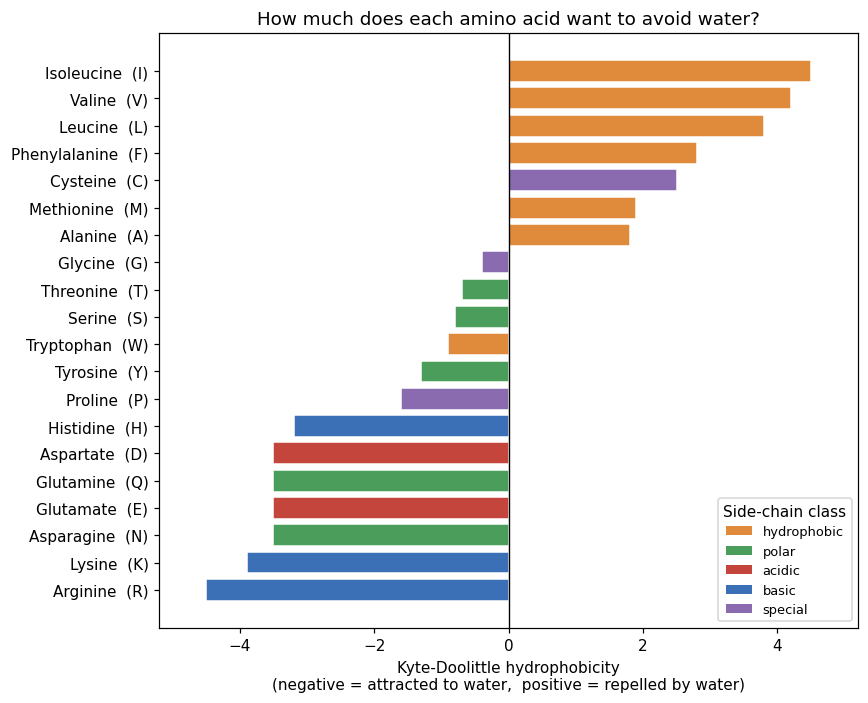

In [5]:
CLASS_COLORS = {
    "hydrophobic": "#E08A3C",   # orange - avoids water
    "polar":       "#4A9D5B",   # green  - hydrogen bonds with water
    "acidic":      "#C4453C",   # red    - negative at pH 7
    "basic":       "#3B6FB6",   # blue   - positive at pH 7
    "special":     "#8A6BAF",   # purple - structural oddballs
}

ordered = aa_table.sort_values("hydrophobicity")

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(ordered["name"] + "  (" + ordered["aa"] + ")", ordered["hydrophobicity"],
        color=[CLASS_COLORS[c] for c in ordered["class"]], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.9)

ax.set_xlabel("Kyte-Doolittle hydrophobicity\n(negative = attracted to water,  positive = repelled by water)")
ax.set_title("How much does each amino acid want to avoid water?")
ax.set_xlim(-5.2, 5.2)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=k) for k, c in CLASS_COLORS.items()],
          loc="lower right", fontsize=8.5, title="Side-chain class")

plt.tight_layout()
plt.show()

### The chart is doing chemistry, not just decoration

Look at how cleanly the colors sort themselves. This is not a coincidence — it's the
periodic-table-level logic of polarity showing up in biology.

**Everything on the positive (right) side is orange or purple.** Isoleucine, valine, leucine,
phenylalanine: these side chains are pure hydrocarbon or aromatic rings. They have no
meaningful dipole moment, so water molecules can't form hydrogen bonds with them. Cysteine
(purple, +2.5) sits up there too — its –SH group is only weakly polar, because sulfur and
hydrogen have nearly identical electronegativities.

**Everything at the far negative (left) end is blue, red, or green.** Arginine bottoms out at
−4.5: its guanidinium group carries a full positive charge spread over three nitrogens, and
a charged group in water is stabilized by strong ion–dipole interactions. Pulling it out of
water would cost a lot of energy. Aspartate and glutamate (red) sit at −3.5 for the mirror-
image reason — full negative charge. Asparagine and glutamine (green) are also at −3.5
despite being *uncharged*, because their amide groups are excellent hydrogen bond donors
**and** acceptors.

**Tryptophan is the interesting exception.** We classified it as hydrophobic — it's a big
aromatic indole ring — yet it scores −0.9, on the water-loving side. That's because the ring
carries an N–H group that can donate a hydrogen bond. Tryptophan is genuinely amphipathic,
and you'll often find it right at the boundary between a protein's core and its surface.
Classification schemes are useful simplifications, not laws of nature, and it's worth
knowing where yours creaks.

Now we have chemistry for all 20 amino acids, and confidence scores for all 148 positions in
lysozyme. Time to put them together.

---

# 3. What is lysozyme made of?

Now we join our two tables: the 148 positions in lysozyme, and the chemistry of the 20 amino
acids. `pandas` does this with `merge()`, matching rows on the shared `aa` column — the same
idea as a lookup in a spreadsheet.

### First, a decision we have to make on purpose

We just discovered that residues 1–18 are a signal peptide that gets **cut off** and is not
part of the working enzyme. So before we analyze anything, we have to answer a question every
experiment has to answer:

> **What exactly is the population we're studying?**

We're asking whether side-chain chemistry explains AlphaFold's confidence *in a folded
protein*. The signal peptide isn't part of the folded protein — it's a shipping label. Mixing
it in would mean testing our idea on a mixture of two completely different things.

So we define our study population as the **mature protein, residues 19–148**, and we do it
*before* looking at any results — not after, once we've seen which choice gives a nicer
answer. That ordering is what separates an analysis from a fishing expedition.

We are not throwing the signal peptide away. We're setting it aside deliberately, and in
section 9 we'll bring it back and see exactly how much difference this one decision makes.

In [6]:
# Join chemistry onto every position in the protein
lyso = lyso.merge(aa_table, on="aa", how="left")
assert lyso["class"].notna().all(), "some residue had no chemistry entry"

SIGNAL_PEPTIDE_END = 18
mature = lyso[lyso["position"] > SIGNAL_PEPTIDE_END].copy()

print(f"Full chain:      {len(lyso)} residues (positions 1-{len(lyso)})")
print(f"Signal peptide:  {SIGNAL_PEPTIDE_END} residues (cleaved off before the enzyme is secreted)")
print(f"Mature enzyme:   {len(mature)} residues (positions {SIGNAL_PEPTIDE_END+1}-{len(lyso)})  <-- our study population")
print()

composition = mature["class"].value_counts()
print("Composition of the mature enzyme:")
for cls_name, n in composition.items():
    print(f"  {cls_name:12s} {n:3d} residues  ({100*n/len(mature):4.1f}%)")

mature[["position", "aa", "name", "class", "hydrophobicity", "charge_at_pH7", "pLDDT"]].head()

Full chain:      148 residues (positions 1-148)
Signal peptide:  18 residues (cleaved off before the enzyme is secreted)
Mature enzyme:   130 residues (positions 19-148)  <-- our study population

Composition of the mature enzyme:
  hydrophobic   45 residues  (34.6%)
  polar         33 residues  (25.4%)
  special       21 residues  (16.2%)
  basic         20 residues  (15.4%)
  acidic        11 residues  ( 8.5%)


,position,aa,name,class,hydrophobicity,charge_at_pH7,pLDDT
18,19,K,Lysine,basic,-3.9,1,95.06
19,20,V,Valine,hydrophobic,4.2,0,98.44
20,21,F,Phenylalanine,hydrophobic,2.8,0,98.69
21,22,E,Glutamate,acidic,-3.5,-1,98.56
22,23,R,Arginine,basic,-4.5,1,98.56


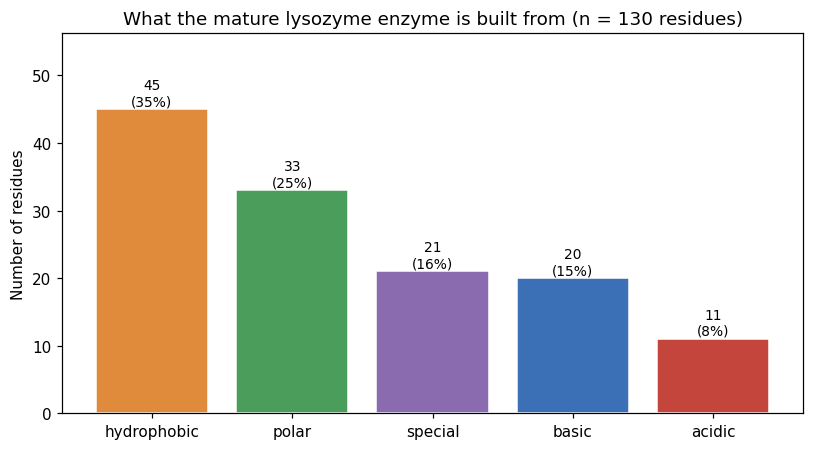

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

order = ["hydrophobic", "polar", "special", "basic", "acidic"]
counts = [composition[c] for c in order]
bars = ax.bar(order, counts, color=[CLASS_COLORS[c] for c in order], edgecolor="white")

for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, n + 0.6,
            f"{n}\n({100*n/len(mature):.0f}%)", ha="center", fontsize=9)

ax.set_ylabel("Number of residues")
ax.set_title(f"What the mature lysozyme enzyme is built from (n = {len(mature)} residues)")
ax.set_ylim(0, max(counts) * 1.25)
plt.tight_layout()
plt.show()

### Reading the composition

Hydrophobic residues are the single largest group — 45 of 130, about 35% of the enzyme.
That's typical, and it's a structural necessity rather than an accident. A protein dissolved
in water needs *something* to hold its folded shape together, and the main thing doing that
job is a core of nonpolar side chains packed away from the solvent.

The charged residues (acidic + basic) come to 31 residues, about 24%. Notice that basic
residues outnumber acidic ones almost 2:1 here. That gives lysozyme a strongly **positive**
net charge at physiological pH — which is not a random detail. Bacterial cell walls are
loaded with negatively charged groups, and Coulombic attraction between the positively
charged enzyme and the negatively charged cell wall helps lysozyme find and stick to its
target. Chemistry you'd meet in AP Chem, doing immunology.

Now for the actual question.

---

# 4. Does confidence differ by side-chain class?

Here's our hypothesis again: **nonpolar residues get buried in the protein's core, buried
residues are locked in place, and locked-in residues should be easier to predict.** If that's
right, hydrophobic residues should have higher pLDDT than charged ones.

To check, we can't just compare the group averages and eyeball it. Any two groups of numbers
will have *slightly* different averages by pure chance. We need to know whether the
difference we see is bigger than the wobble we'd expect from chance alone.

### Three numbers that sound similar and are not

This trips up almost everyone the first time, so let's be precise.

**Standard deviation (SD)** — how spread out the *individual residues* are. A big SD means
the residues in that group have wildly different scores from each other. SD describes the
data you have.

**Standard error (SE)** — how much the *group average* would bounce around if you repeated
the whole study. It's the SD divided by √n. Notice what that means: measuring more residues
doesn't make the individual residues less variable (SD stays put), but it does pin down the
average more tightly (SE shrinks). SE describes how well you know the average.

**95% confidence interval (CI)** — a range built from the SE, roughly `mean ± 2 × SE`. The
honest interpretation: if we repeated this entire procedure many times, about 95% of the
intervals we'd build would contain the true average. It is a statement about the *method's*
reliability, not a promise about this one interval.

The practical rule we'll use: **if two groups' confidence intervals overlap a lot, we don't
have strong evidence that their true averages differ.**

In [8]:
summary_rows = []
for cls_name in order:
    vals = mature.loc[mature["class"] == cls_name, "pLDDT"]
    sem = stats.sem(vals)
    ci_low, ci_high = stats.t.interval(0.95, len(vals) - 1, loc=vals.mean(), scale=sem)
    summary_rows.append({
        "class": cls_name,
        "n": len(vals),
        "mean_pLDDT": round(vals.mean(), 2),
        "SD": round(vals.std(), 2),
        "SE": round(sem, 3),
        "CI_low": round(ci_low, 2),
        "CI_high": round(ci_high, 2),
    })

class_summary = pd.DataFrame(summary_rows)
print("pLDDT by side-chain class, mature enzyme only:\n")
class_summary

pLDDT by side-chain class, mature enzyme only:



,class,n,mean_pLDDT,SD,SE,CI_low,CI_high
0,hydrophobic,45,98.56,0.57,0.085,98.38,98.73
1,polar,33,98.48,0.48,0.083,98.31,98.65
2,special,21,98.24,0.82,0.178,97.87,98.61
3,basic,20,98.32,0.83,0.186,97.93,98.71
4,acidic,11,98.03,1.13,0.341,97.27,98.79


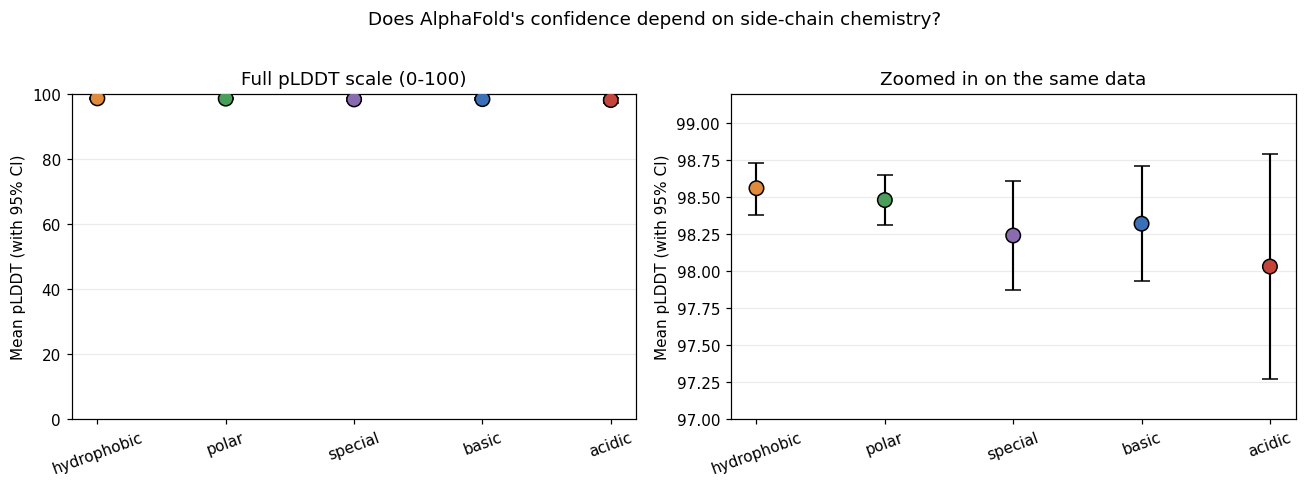

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

x = np.arange(len(class_summary))
colors = [CLASS_COLORS[c] for c in class_summary["class"]]
err = [class_summary["mean_pLDDT"] - class_summary["CI_low"],
       class_summary["CI_high"] - class_summary["mean_pLDDT"]]

for ax, (lo, hi), title in [
    (ax1, (0, 100), "Full pLDDT scale (0-100)"),
    (ax2, (97.0, 99.2), "Zoomed in on the same data"),
]:
    ax.errorbar(x, class_summary["mean_pLDDT"], yerr=err, fmt="none",
                ecolor="black", capsize=5, linewidth=1.4, zorder=3)
    ax.scatter(x, class_summary["mean_pLDDT"], s=90, c=colors,
               edgecolor="black", zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(class_summary["class"], rotation=20)
    ax.set_ylim(lo, hi)
    ax.set_ylabel("Mean pLDDT (with 95% CI)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Does AlphaFold's confidence depend on side-chain chemistry?", y=1.02)
plt.tight_layout()
plt.show()

### Look at those two panels side by side

Same numbers. Same error bars. Completely different impression.

On the **left**, plotted on the real 0–100 scale that pLDDT actually lives on, all five
classes are indistinguishable. The dots sit on top of each other and the error bars are too
small to even see.

On the **right**, we zoomed the y-axis to a 2.2-unit window and suddenly there appear to be
dramatic differences between classes, with acidic residues way down at the bottom.

**Nothing changed except the axis.** This is one of the most common ways charts mislead
people — including the person making them. Whenever you see a bar chart with a suspiciously
narrow y-axis, or one that doesn't start at zero, ask what it would look like at full scale.

The left panel is telling the truth: every class averages between **98.03 and 98.56**, a
spread of about half a point on a hundred-point scale. Notice also that the acidic group's
error bars are much wider — that's because there are only 11 acidic residues versus 45
hydrophobic ones, and SE shrinks with √n. Small group, fuzzy estimate.

Let's put a number on it anyway.

In [10]:
hydrophobic = mature.loc[mature["class"] == "hydrophobic", "pLDDT"]
charged = mature.loc[mature["class"].isin(["acidic", "basic"]), "pLDDT"]

t_stat, p_value = stats.ttest_ind(hydrophobic, charged, equal_var=False)   # Welch's t-test

# Cohen's d: how big is the gap, measured in standard deviations?
pooled_sd = np.sqrt(((len(hydrophobic) - 1) * hydrophobic.var(ddof=1) +
                     (len(charged) - 1) * charged.var(ddof=1)) /
                    (len(hydrophobic) + len(charged) - 2))
cohens_d = (hydrophobic.mean() - charged.mean()) / pooled_sd

print("Hypothesis: hydrophobic residues have HIGHER pLDDT than charged residues")
print("-" * 62)
print(f"Hydrophobic:  n = {len(hydrophobic):3d}   mean = {hydrophobic.mean():.2f}   SD = {hydrophobic.std():.2f}")
print(f"Charged:      n = {len(charged):3d}   mean = {charged.mean():.2f}   SD = {charged.std():.2f}")
print(f"Difference:                  {hydrophobic.mean() - charged.mean():+.2f} pLDDT points")
print()
print(f"Welch's t-test:   t = {t_stat:.3f},  p = {p_value:.4f}")
print(f"Cohen's d:        d = {cohens_d:.3f}")
print()
print("Verdict at the conventional 0.05 threshold:",
      "REJECT the null" if p_value < 0.05 else "FAIL to reject the null (no convincing evidence)")

Hypothesis: hydrophobic residues have HIGHER pLDDT than charged residues
--------------------------------------------------------------
Hydrophobic:  n =  45   mean = 98.56   SD = 0.57
Charged:      n =  31   mean = 98.22   SD = 0.94
Difference:                  +0.34 pLDDT points

Welch's t-test:   t = 1.795,  p = 0.0794
Cohen's d:        d = 0.457

Verdict at the conventional 0.05 threshold: FAIL to reject the null (no convincing evidence)


### Our hypothesis just failed, and that's fine

The difference goes in the predicted direction — hydrophobic residues do average slightly
higher — but **p = 0.079**, above the conventional 0.05 cutoff. In plain language:

> If side-chain chemistry made no difference at all to pLDDT, we'd still see a gap this big
> or bigger about 8% of the time, purely by chance. That's not rare enough to be convincing.

Three things worth taking from this.

**1. A *p*-value is not the probability that your hypothesis is wrong.** It's the probability
of seeing data at least this extreme *if the null hypothesis were true*. Those are genuinely
different statements, and mixing them up is the single most common statistical error in
published science.

**2. Effect size and significance are different questions.** Cohen's *d* = 0.457 is a
"moderate" effect by the usual rule of thumb — but *d* is measured in standard deviations,
and the standard deviations here are tiny (0.57 and 0.94 points). Half a standard deviation
of almost nothing is still almost nothing. Always ask "how big, in units I care about?"
alongside "is it significant?" Here the answer is **0.34 pLDDT points** on a 100-point scale.
Nobody would make a different decision about a protein based on that.

**3. There's a reason the effect is invisible: we've hit a ceiling.** Across the entire mature
enzyme, pLDDT runs from 95.1 to 98.9 with a standard deviation of just 0.71. AlphaFold is
essentially *maxed out* on this protein. You cannot detect what makes confidence vary when
confidence barely varies. A well-folded protein is a wonderfully clean subject in every way
except this one — there's no variation left to explain.

That's a real, honest finding, and reporting it is not a failure. Papers that only ever
confirm their hypothesis should make you suspicious.

But before we give up on chemistry, we should ask whether we tested the right thing.

---

# 5. Comparing all five classes at once

We only compared two groups. But we have five classes — why not just run a *t*-test on every
pair and see which ones come out significant?

Because that's a trap, and it has a name: the **multiple comparisons problem**.

With 5 classes there are 10 possible pairs. Suppose chemistry has *no* effect whatsoever, and
we test all 10 pairs at the usual 0.05 threshold. Each individual test has a 5% chance of a
false alarm. The chance of getting **at least one** false alarm across 10 independent tests is:

$$1 - (0.95)^{10} \approx 0.40$$

**Forty percent.** Run enough tests on pure noise and something will look significant, and
then it's terribly tempting to write the paper about that one. This is why "we tested many
things and here's the one that worked" is a warning sign rather than a selling point.

### The fix: ask one question instead of ten

A **one-way ANOVA** (Analysis of Variance) asks a single question covering all five groups at
once:

> Is the variation *between* the class averages bigger than the variation *within* each class?

That ratio is the **F-statistic**:

$$F = \frac{\text{variation between groups}}{\text{variation within groups}}$$

If chemistry doesn't matter, the group averages should differ only as much as random
sampling would make them differ, and *F* should land near 1. Much larger than 1 means the
groups are further apart than noise can explain.

In [11]:
groups = [mature.loc[mature["class"] == c, "pLDDT"].values for c in order]

f_stat, p_anova = stats.f_oneway(*groups)

print("One-way ANOVA: does mean pLDDT differ across the five side-chain classes?")
print("-" * 70)
print(f"  H0: all five class means are equal")
print(f"  H1: at least one class mean differs")
print()
for cls_name, g in zip(order, groups):
    print(f"  {cls_name:12s} n = {len(g):3d}   mean = {g.mean():.2f}")
print()
print(f"  F = {f_stat:.3f}")
print(f"  p = {p_anova:.4f}")
print()
print("Conclusion:", "at least one class differs" if p_anova < 0.05
      else "no evidence that any class differs from the others")

One-way ANOVA: does mean pLDDT differ across the five side-chain classes?
----------------------------------------------------------------------
  H0: all five class means are equal
  H1: at least one class mean differs

  hydrophobic  n =  45   mean = 98.56
  polar        n =  33   mean = 98.48
  special      n =  21   mean = 98.24
  basic        n =  20   mean = 98.32
  acidic       n =  11   mean = 98.03

  F = 1.785
  p = 0.1359

Conclusion: no evidence that any class differs from the others


### The ANOVA agrees with the *t*-test

*F* = 1.785 is close to 1 — the spread *between* our five class averages is barely larger
than the spread *within* each class. With *p* = 0.1359 we have no evidence that side-chain
chemistry affects how confident AlphaFold is about a residue in this protein.

Two sections in, our original hypothesis is not holding up.

Here's the thing though. We may have been asking a slightly wrong question. Our reasoning had
two links in the chain:

> nonpolar side chains get **buried in the core** → buried residues are **easier to predict**

We've been testing the *end* of that chain, and we've discovered we can't test it here,
because AlphaFold is pinned at ~98 for the entire folded enzyme and there's no variation left
to explain.

But the *first* link is a completely separate claim — and it's the one that's actually about
chemistry. Do nonpolar residues really end up buried?

That question doesn't involve pLDDT at all. To answer it we need the one thing we downloaded
and haven't touched yet: **the actual 3D coordinates**.

---

# 6. What does this look like in 3D?

The PDB file we cached contains the x, y, z position of every atom, in ångströms
(1 Å = 10⁻¹⁰ m — about the width of a hydrogen atom).

We'll simplify by tracking just one atom per residue: the **α-carbon**, the central carbon
that carries the side chain. 130 α-carbons give us the shape of the protein's backbone
without drowning in the ~1000 other atoms.

We use `biopython`'s PDB parser to read the file — the same library structural biologists
use, so it handles all the formatting quirks of the PDB format for us.

In [12]:
from Bio.PDB import PDBParser

structure = PDBParser(QUIET=True).get_structure("lysozyme", DATA_DIR / "lysozyme.pdb")
chain = next(structure[0].get_chains())

residues = [res for res in chain if "CA" in res]
coords = np.array([res["CA"].get_coord() for res in residues], dtype=float)
pdb_positions = np.array([res.get_id()[1] for res in residues])

# The coordinates must line up with our table, or every result after this is meaningless.
assert np.array_equal(pdb_positions, lyso["position"].values), "PDB numbering does not match our table"

lyso[["x", "y", "z"]] = coords
mature = lyso[lyso["position"] > SIGNAL_PEPTIDE_END].copy()

print(f"Parsed {len(coords)} alpha-carbon coordinates.")
print(f"Bounding box of the whole chain: {np.ptp(coords, axis=0).round(1)} angstroms (x, y, z)")
print()

# How compact is the folded part, and where does the signal peptide sit relative to it?
core = coords[SIGNAL_PEPTIDE_END:]
tail = coords[:SIGNAL_PEPTIDE_END]
core_center = core.mean(axis=0)
core_dist = np.linalg.norm(core - core_center, axis=1)
tail_dist = np.linalg.norm(tail - core_center, axis=1)

print(f"Folded enzyme:   radius of gyration {np.sqrt((core_dist**2).mean()):.1f} A, "
      f"no residue further than {core_dist.max():.1f} A from its center")
print(f"Signal peptide:  reaches {tail_dist.max():.1f} A from that same center")
print(f"                 end-to-end length {np.linalg.norm(tail[0] - tail[-1]):.1f} A "
      f"(a fully stretched 18-residue chain would be about {17*3.5:.0f} A)")
print()
print(lyso[["position", "aa", "class", "x", "y", "z"]].head())

Parsed 148 alpha-carbon coordinates.
Bounding box of the whole chain: [64.1 43.2 35.4] angstroms (x, y, z)

Folded enzyme:   radius of gyration 13.8 A, no residue further than 22.1 A from its center
Signal peptide:  reaches 60.1 A from that same center
                 end-to-end length 48.6 A (a fully stretched 18-residue chain would be about 60 A)

   position aa        class          x          y          z
0         1  M  hydrophobic  48.612000  28.230000  20.181000
1         2  K        basic  46.037998  27.683001  17.358999
2         3  A  hydrophobic  42.953999  25.885000  18.664000
3         4  L  hydrophobic  40.363998  25.514999  15.851000
4         5  I  hydrophobic  37.332001  23.569000  16.653999


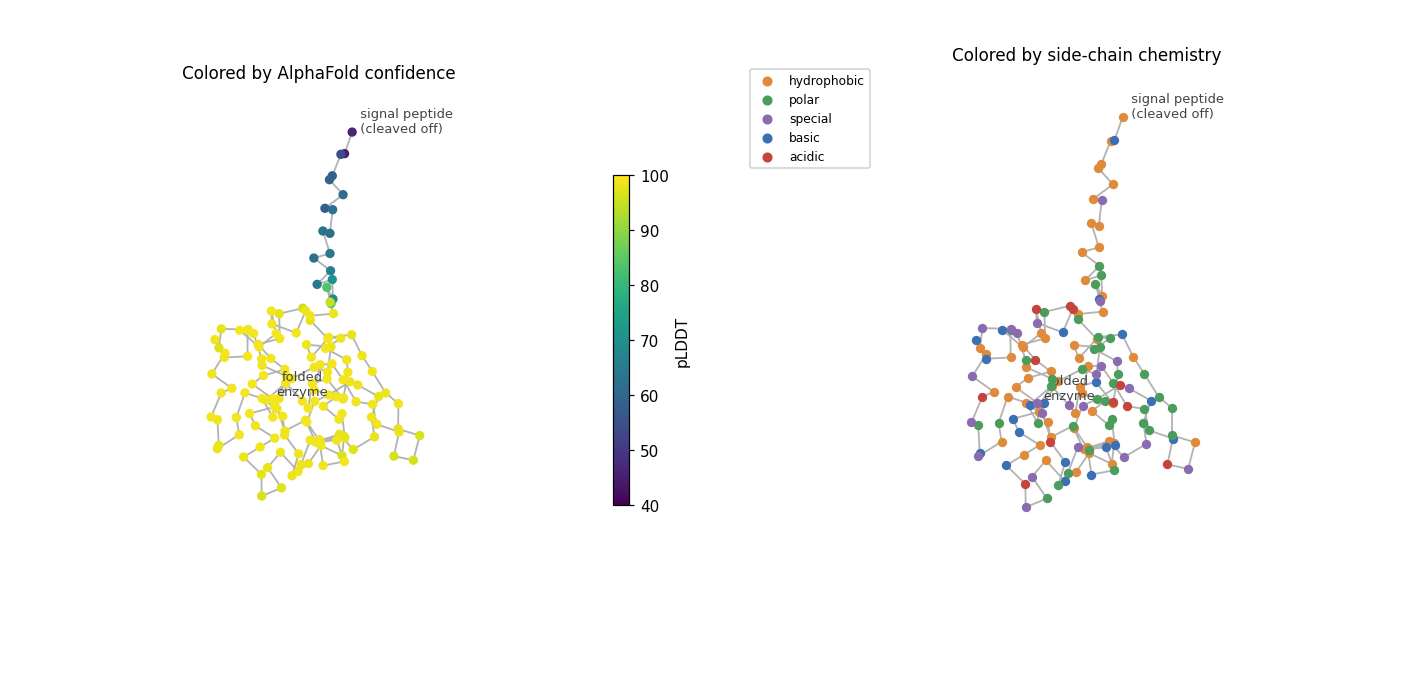

In [13]:
fig = plt.figure(figsize=(13, 6))
XYZ = lyso[["x", "y", "z"]].values

# --- Left: the backbone colored by confidence ---
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(*XYZ.T, color="0.7", linewidth=1.2, zorder=1)
sc = ax1.scatter(*XYZ.T, c=lyso["pLDDT"], cmap="viridis", s=26,
                 vmin=40, vmax=100, depthshade=False, zorder=2)
ax1.set_title("Colored by AlphaFold confidence", y=0.99, fontsize=11)
fig.colorbar(sc, ax=ax1, shrink=0.5, pad=-0.02, label="pLDDT")

# --- Right: the same backbone colored by side-chain chemistry ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(*XYZ.T, color="0.7", linewidth=1.2, zorder=1)
for cls_name in order:
    sub = lyso.loc[lyso["class"] == cls_name, ["x", "y", "z"]].values
    ax2.scatter(*sub.T, c=CLASS_COLORS[cls_name], s=26, label=cls_name,
                depthshade=False, zorder=2)
ax2.set_title("Colored by side-chain chemistry", y=0.99, fontsize=11)
ax2.legend(loc="upper left", fontsize=8, markerscale=1.1, framealpha=0.9,
           bbox_to_anchor=(-0.02, 0.92))

for ax in (ax1, ax2):
    # Equal aspect in all three axes, so the molecule isn't stretched by the plot
    ax.set_box_aspect(np.ptp(XYZ, axis=0))
    ax.view_init(elev=25, azim=-140)
    ax.set_axis_off()
    ax.text(*tail[0], "  signal peptide\n  (cleaved off)", fontsize=8.5, color="#444444")
    ax.text(*core_center, "folded\nenzyme", fontsize=8.5, color="#444444", ha="center")

fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0, wspace=0.02)
plt.show()

### What the 3D plot shows

The dense tangle is the folded enzyme: 130 residues packed into a ball with a radius of
gyration of just 13.8 Å, and not one residue further than 22.1 Å from its center. In the
left panel it's uniformly yellow — high confidence everywhere.

Shooting away from it is the **signal peptide**, and now you can see why its scores were low.
It doesn't tuck back into the globule. It runs out into empty space, 48.6 Å from end to end —
close to the ~60 Å you'd get from an 18-residue chain pulled completely straight — and its
last residue sits 60.1 Å from the enzyme's center, nearly three times further out than any
part of the folded protein. Along that stretch the color slides from yellow through teal to
dark purple as AlphaFold's confidence drains away.

This is the picture behind the numbers from section 1. A low pLDDT region isn't a fold that
AlphaFold got wrong. It's a piece of chain with nothing to hold onto, and AlphaFold saying so.

Now look at the right panel, at the folded globule, and try to decide whether the orange
(hydrophobic) dots sit *inside* while the blue and red (charged) dots sit *outside*. It's
suggestive — but on a flat picture of a 3D object, with 130 overlapping points, can you
honestly tell? Your eye will happily find whichever pattern you went looking for.

That's exactly why we measure instead of squint.

In [14]:
import py3Dmol

def show_structure(color_by):
    view = py3Dmol.view(width=760, height=460)
    view.addModel(pdb_text, "pdb")
    view.setStyle({"cartoon": {"color": "#DDDDDD"}})

    if color_by == "confidence":
        for low, high, color, _label in BANDS:
            sel = lyso.loc[(lyso["pLDDT"] >= low) & (lyso["pLDDT"] < high), "position"].tolist()
            if sel:
                view.setStyle({"resi": sel}, {"cartoon": {"color": color}})
    else:
        for cls_name in order:
            sel = lyso.loc[lyso["class"] == cls_name, "position"].tolist()
            view.setStyle({"resi": sel}, {"cartoon": {"color": CLASS_COLORS[cls_name]}})
            # show the actual side chains so you can see which way they point
            if cls_name == "hydrophobic":
                view.addStyle({"resi": sel}, {"stick": {"color": CLASS_COLORS[cls_name], "radius": 0.15}})

    view.zoomTo()
    return view

# AlphaFold's official four-band coloring: dark blue = very high, orange = very low
print("Interactive view 1 - confidence. Drag to rotate, scroll to zoom.")
show_structure("confidence").show()

Interactive view 1 - confidence. Drag to rotate, scroll to zoom.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [15]:
print("Interactive view 2 - side-chain chemistry, with hydrophobic side chains drawn as sticks.")
show_structure("chemistry").show()

Interactive view 2 - side-chain chemistry, with hydrophobic side chains drawn as sticks.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### About these two views

*(These are live 3D viewers. They need a running Python kernel, so if you're reading this on
GitHub you'll see a blank space here — run the notebook yourself to spin the molecule around.
The matplotlib figure above is a static substitute that always renders.)*

**View 1** uses AlphaFold's official four-band coloring. The enzyme is solid dark blue; only
the signal peptide tail picks up yellow and orange.

**View 2** colors the backbone by side-chain class and draws the hydrophobic side chains as
sticks. Rotate it and watch what the orange sticks do: they overwhelmingly point *inward*,
toward the middle of the globule. The blue and red backbone segments — lysine, arginine,
aspartate, glutamate — are out on the surface, where their charges stay solvated.

That's the hydrophobic effect, and it's the thing we should have been measuring all along.
Let's measure it.

---

# 7. Are nonpolar residues really buried?

New question, and notice it doesn't mention AlphaFold's confidence at all:

> **Do hydrophobic residues actually end up in the interior of the folded protein?**

This is the *chemistry* half of our original reasoning, and unlike pLDDT it isn't pinned at a
ceiling. Let's test it.

### First we need to measure "buried"

There's no column in the PDB file that says buried or exposed. We have to build that
measurement ourselves out of coordinates.

The professional answer is **solvent-accessible surface area** — you roll a virtual
water-sized sphere over the protein and record how much of each residue it can touch. It's
the right tool, and it needs specialized software.

We'll use a simpler stand-in that captures the same idea, called the **contact number**:

> For each residue, count how many *other* residues have their α-carbon within 10 Å.

The logic is just geometry. A residue in the middle of the protein is surrounded on all sides,
so lots of neighbors fall inside its 10 Å bubble. A residue on the surface has protein on one
side and open water on the other, so it has fewer. **High contact number = buried. Low
contact number = exposed.**

### Two honest caveats before we use it

**This is a proxy, not the real thing.** Contact number correlates well with true burial, but
it isn't the same measurement, and a big residue like tryptophan can be quite exposed while
still having plenty of α-carbons nearby. When you use a stand-in for the thing you actually
care about, you should say so out loud — every time.

**The 10 Å cutoff is a choice we made.** Not a law of nature. A different cutoff would give
different raw numbers. What matters is that we pick it *before* looking at the results and
then keep it fixed, rather than trying several and keeping whichever gives the nicest answer.

One more detail: we compute neighbors using **only the mature enzyme's residues**. The signal
peptide gets cleaved off, so in the real working protein it simply isn't there to be anyone's
neighbor. Including it would credit residues near its attachment point with neighbors that
don't exist.

In [16]:
CONTACT_RADIUS = 10.0   # angstroms - chosen before looking at any results

mature_xyz = mature[["x", "y", "z"]].values

# Distance from every mature residue to every other mature residue
distances = np.linalg.norm(mature_xyz[:, None, :] - mature_xyz[None, :, :], axis=-1)

# Count neighbours within the cutoff, excluding the residue itself (distance 0)
mature["contacts"] = ((distances < CONTACT_RADIUS) & (distances > 0)).sum(axis=1)

print(f"Contact number = neighbours within {CONTACT_RADIUS:.0f} A, computed over the "
      f"{len(mature)} mature residues only")
print(f"  range:  {mature['contacts'].min()} to {mature['contacts'].max()} neighbours")
print(f"  median: {mature['contacts'].median():.0f}")
print()

most_buried = mature.nlargest(5, "contacts")[["position", "aa", "name", "class", "contacts"]]
most_exposed = mature.nsmallest(5, "contacts")[["position", "aa", "name", "class", "contacts"]]
print("Five most BURIED residues:")
print(most_buried.to_string(index=False))
print()
print("Five most EXPOSED residues:")
print(most_exposed.to_string(index=False))

Contact number = neighbours within 10 A, computed over the 130 mature residues only
  range:  6 to 30 neighbours
  median: 17

Five most BURIED residues:
 position aa          name       class  contacts
       74  I    Isoleucine hydrophobic        30
       75  F Phenylalanine hydrophobic        29
       47  M    Methionine hydrophobic        28
       49  L       Leucine hydrophobic        28
       72  Y      Tyrosine       polar        27

Five most EXPOSED residues:
 position aa       name       class  contacts
       66  G    Glycine     special         6
       65  A    Alanine hydrophobic         8
      136  N Asparagine       polar         8
      147  G    Glycine     special         8
      121  P    Proline     special         9


### A first look, before any statistics

The buried list is exactly what we hoped for: isoleucine, phenylalanine, methionine, leucine
— nonpolar, all four of them. (Tyrosine at number five is a useful reminder that our five
classes are a simplification. Its big flat aromatic ring packs beautifully into a core even
though the –OH group makes it polar.)

The exposed list is more surprising. Glycine, alanine, asparagine, glycine, proline — not the
charged residues you might have expected. That's worth pausing on, because it exposes
something about our measurement: **contact number is partly measuring residue size and local
chain geometry, not purely "buriedness."** Glycine's side chain is a single hydrogen atom and
alanine's is a methyl group; they're tiny, they show up constantly in surface loops where the
chain is spread out, and few α-carbons land in their 10 Å bubble as a result.

This is what a proxy measurement looks like when you inspect it honestly. It's still useful —
we're about to show it carries real signal — but it isn't measuring only the thing we named it
after. Noticing that now is better than being surprised by it later.

Either way, five residues out of 130 is an anecdote, and we chose them precisely *because*
they were extreme. Let's look at all 130 at once.

In [17]:
burial_rows = []
for cls_name in order:
    vals = mature.loc[mature["class"] == cls_name, "contacts"]
    ci_low, ci_high = stats.t.interval(0.95, len(vals) - 1,
                                       loc=vals.mean(), scale=stats.sem(vals))
    burial_rows.append({"class": cls_name, "n": len(vals),
                        "mean_contacts": round(vals.mean(), 2),
                        "SD": round(vals.std(), 2),
                        "CI_low": round(ci_low, 2), "CI_high": round(ci_high, 2)})

burial_summary = pd.DataFrame(burial_rows)

f_burial, p_burial = stats.f_oneway(*[mature.loc[mature["class"] == c, "contacts"].values
                                      for c in order])

print("How buried is each side-chain class?\n")
print(burial_summary.to_string(index=False))
print()
print(f"One-way ANOVA:  F = {f_burial:.3f},  p = {p_burial:.5f}")
print("Conclusion:", "the classes differ in burial" if p_burial < 0.05
      else "no evidence the classes differ in burial")

How buried is each side-chain class?

      class  n  mean_contacts   SD  CI_low  CI_high
hydrophobic 45          19.71 4.88   18.24    21.18
      polar 33          17.79 5.08   15.99    19.59
    special 21          15.76 6.05   13.01    18.52
      basic 20          14.90 3.37   13.32    16.48
     acidic 11          15.73 5.27   12.18    19.27

One-way ANOVA:  F = 4.595,  p = 0.00170
Conclusion: the classes differ in burial


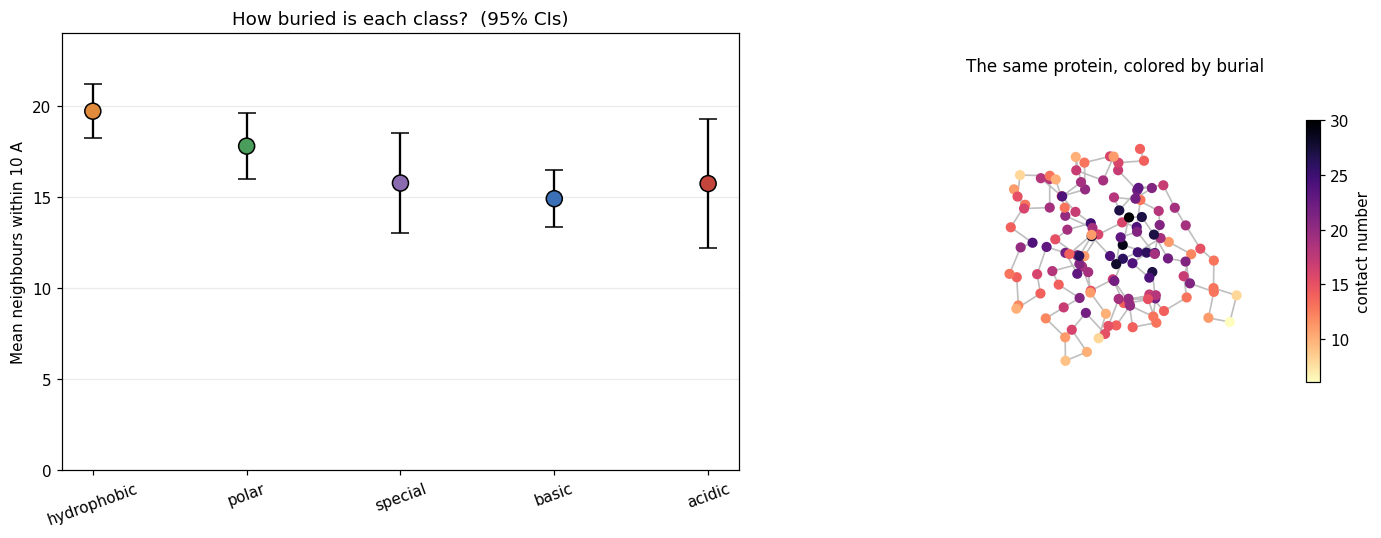

In [18]:
fig = plt.figure(figsize=(13, 5))

# --- Left: mean contact number per class, with 95% CIs, on the full scale ---
ax1 = fig.add_subplot(1, 2, 1)
x = np.arange(len(burial_summary))
err = [burial_summary["mean_contacts"] - burial_summary["CI_low"],
       burial_summary["CI_high"] - burial_summary["mean_contacts"]]
ax1.errorbar(x, burial_summary["mean_contacts"], yerr=err, fmt="none",
             ecolor="black", capsize=6, linewidth=1.5, zorder=3)
ax1.scatter(x, burial_summary["mean_contacts"], s=110,
            c=[CLASS_COLORS[c] for c in burial_summary["class"]],
            edgecolor="black", zorder=4)
ax1.set_xticks(x)
ax1.set_xticklabels(burial_summary["class"], rotation=20)
ax1.set_ylabel(f"Mean neighbours within {CONTACT_RADIUS:.0f} A")
ax1.set_ylim(0, 24)
ax1.set_title("How buried is each class?  (95% CIs)")
ax1.grid(axis="y", alpha=0.25)

# --- Right: the protein in 3D, colored by how buried each residue is ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(*mature_xyz.T, color="0.75", linewidth=1.1, zorder=1)
sc = ax2.scatter(*mature_xyz.T, c=mature["contacts"], cmap="magma_r",
                 s=32, depthshade=False, zorder=2)
ax2.set_box_aspect(np.ptp(mature_xyz, axis=0))
ax2.view_init(elev=25, azim=-140)
ax2.set_axis_off()
ax2.set_title("The same protein, colored by burial", y=0.97, fontsize=11)
fig.colorbar(sc, ax=ax2, shrink=0.6, pad=-0.04, label="contact number")

plt.tight_layout()
plt.show()

### Now we have a real effect

Compare this to the flat, overlapping picture from section 4. Here the classes genuinely
separate:

- **Hydrophobic: 19.71 neighbours** on average, 95% CI [18.24, 21.18]
- **Basic: 14.90 neighbours**, 95% CI [13.32, 16.48]

Those two intervals **don't overlap at all** — the hydrophobic interval stops at 18.24 and the
basic interval stops at 16.48, with a clear gap between them. That's the visual signature of a
difference we can actually believe. The ANOVA agrees: *F* = 4.595, *p* = 0.00170.

And look at the 3D panel on the right. The dark, high-contact residues form a solid clump in
the middle of the protein; the pale, low-contact ones form a shell around the outside. The
protein has a genuine **core** and a genuine **surface**, and we found them using nothing but
distances between carbon atoms.

### Why this happens — the actual thermodynamics

It's tempting to say nonpolar side chains "hate water" or are "repelled" by it. That's not
quite what's going on, and the real explanation is better AP Chemistry.

Water molecules hydrogen-bond with each other constantly, in a shifting network. Drop a
nonpolar side chain into that network and the water can't hydrogen-bond *to* it — so the water
molecules touching its surface have to arrange themselves into a more ordered cage-like shell
to keep bonding to each other. Ordered water means **lower entropy**.

Now bury that nonpolar group in the protein's core alongside other nonpolar groups. The
ordered cages are no longer needed and those water molecules are released back into the bulk
liquid, free to tumble again. **Entropy goes up.**

Look at what that means in ΔG = ΔH − TΔS. The folding is driven by a *favorable entropy
change in the water*, not by any attraction between the nonpolar groups themselves. The
hydrophobic effect is mostly an entropy effect, and it's happening in the solvent rather than
in the protein. Meanwhile the charged residues stay outside because a charge in water gets
strong stabilization from ion–dipole interactions — burying one in a greasy core would cost
far too much energy.

Let's confirm this with one more test, of a different kind.

### A different kind of question needs a different kind of test

Everything we've tested so far compared **averages** of numbers. But sometimes you want to
compare **counts in categories** — and for that, *t*-tests and ANOVA don't apply.

So let's ask it as a counting question. Split the residues two ways:

- **Buried or exposed?** (contact number above or below the median)
- **Hydrophobic or not?**

That gives four buckets. If chemistry had nothing to do with position, the hydrophobic
residues should be split between buried and exposed in roughly the same proportion as
everyone else.

The **chi-square test** measures how far the counts we observed are from the counts we'd
*expect* if the two categories were unrelated:

$$\chi^2 = \sum \frac{(\text{observed} - \text{expected})^2}{\text{expected}}$$

Every cell contributes. If observed ≈ expected everywhere, χ² is near zero and the categories
look independent. The bigger χ² gets, the harder it is to explain the pattern as chance.

In [19]:
median_contacts = mature["contacts"].median()
mature["buried"] = mature["contacts"] > median_contacts
mature["is_hydrophobic"] = mature["class"] == "hydrophobic"

table = pd.crosstab(mature["is_hydrophobic"], mature["buried"])
table.index = ["Not hydrophobic", "Hydrophobic"]
table.columns = ["Exposed", "Buried"]

chi2, p_chi, dof, expected = stats.chi2_contingency(table)

print(f"Buried = more than {median_contacts:.0f} neighbours (the median)\n")
print("OBSERVED counts:")
print(table.to_string())
print()
print("EXPECTED counts, if chemistry and position were unrelated:")
print(pd.DataFrame(expected.round(1), index=table.index, columns=table.columns).to_string())
print()
pct_hydro = 100 * table.loc["Hydrophobic", "Buried"] / table.loc["Hydrophobic"].sum()
pct_other = 100 * table.loc["Not hydrophobic", "Buried"] / table.loc["Not hydrophobic"].sum()
print(f"Buried share:  hydrophobic {pct_hydro:.1f}%   |   everything else {pct_other:.1f}%")
print()
print(f"Chi-square:  X2 = {chi2:.3f},  df = {dof},  p = {p_chi:.5f}")

odds_ratio = ((table.loc["Hydrophobic", "Buried"] * table.loc["Not hydrophobic", "Exposed"]) /
              (table.loc["Hydrophobic", "Exposed"] * table.loc["Not hydrophobic", "Buried"]))
print(f"Odds ratio:  {odds_ratio:.2f}")

Buried = more than 17 neighbours (the median)

OBSERVED counts:
                 Exposed  Buried
Not hydrophobic       53      32
Hydrophobic           15      30

EXPECTED counts, if chemistry and position were unrelated:
                 Exposed  Buried
Not hydrophobic     44.5    40.5
Hydrophobic         23.5    21.5

Buried share:  hydrophobic 66.7%   |   everything else 37.6%

Chi-square:  X2 = 8.803,  df = 1,  p = 0.00301
Odds ratio:  3.31


### The hydrophobic effect, in four numbers

**Two-thirds of hydrophobic residues are buried (66.7%), versus just over a third of
everything else (37.6%).** The expected table shows what we'd have seen if position and
chemistry were unrelated — about 21.5 buried hydrophobic residues. We observed 30.

χ² = 8.803 with 1 degree of freedom gives *p* = 0.00301. Roughly: if chemistry had nothing to
do with whether a residue ends up buried, we'd see a pattern this lopsided about 3 times in
1000. That's strong evidence.

The **odds ratio of 3.31** puts it in plainer language: the odds of being buried are about
3.3 times higher for a hydrophobic residue than for a non-hydrophobic one. Unlike the
*p*-value, that number tells you *how much* — and reporting both is a good habit.

### Where we stand

| What we tested | Result |
|---|---|
| Chemistry → AlphaFold's confidence (section 4) | *p* = 0.0794, no evidence |
| Chemistry → all five classes' confidence (section 5) | *p* = 0.1359, no evidence |
| **Chemistry → burial in the core (section 7)** | ***p* = 0.00170 and 0.00301, strong evidence** |

The first link of our chain is solid. Nonpolar residues really do get buried, and we measured
it three different ways. It's the second link — burial predicting AlphaFold's confidence —
that we couldn't test, because in a well-folded enzyme AlphaFold is confident about
essentially everything.

So: how strong is that first relationship, really?

---

# 8. How strong is the relationship, really?

We've shown hydrophobic residues are *more buried*. But "hydrophobic" versus "not
hydrophobic" throws away most of what we know. Leucine (+3.8) and alanine (+1.8) are both in
the hydrophobic bucket, yet they're not equally nonpolar.

The Kyte–Doolittle scale gives us a **number** for every residue. So instead of comparing
groups, let's ask a sharper question:

> As a residue's hydrophobicity increases, does its burial increase *proportionally*?

That's a job for **linear regression** — drawing the straight line that best fits the cloud of
points, where "best" means it minimizes the sum of the squared vertical distances from the
points to the line.

Two numbers come out of it:

**The correlation coefficient *r*** runs from −1 to +1. Positive means the variables rise
together, negative means one rises as the other falls, zero means no linear relationship.

**The coefficient of determination *r²*** is just *r* squared, and it answers "what fraction
of the variation in y is explained by x?" This is the number that keeps people honest, and
it's the one that usually gets left out of headlines.

In [20]:
fit = stats.linregress(mature["hydrophobicity"], mature["contacts"])
predicted = fit.intercept + fit.slope * mature["hydrophobicity"]
residuals = mature["contacts"] - predicted

print("Linear regression:  contact number ~ hydrophobicity")
print("-" * 52)
print(f"  slope       = {fit.slope:+.3f} neighbours per hydrophobicity unit")
print(f"  intercept   = {fit.intercept:.2f} neighbours")
print(f"  r           = {fit.rvalue:+.3f}")
print(f"  r-squared   = {fit.rvalue**2:.3f}   ->  {100*fit.rvalue**2:.1f}% of the variation explained")
print(f"  p-value     = {fit.pvalue:.2e}")
print()
print(f"  Predicted burial for arginine  (hydrophobicity -4.5): {fit.intercept + fit.slope*-4.5:.1f} neighbours")
print(f"  Predicted burial for isoleucine (hydrophobicity +4.5): {fit.intercept + fit.slope*4.5:.1f} neighbours")
print()
print(f"  Spread of the actual points around the line (SD of residuals): {residuals.std():.2f} neighbours")

Linear regression:  contact number ~ hydrophobicity
----------------------------------------------------
  slope       = +0.552 neighbours per hydrophobicity unit
  intercept   = 17.78 neighbours
  r           = +0.320
  r-squared   = 0.102   ->  10.2% of the variation explained
  p-value     = 2.10e-04

  Predicted burial for arginine  (hydrophobicity -4.5): 15.3 neighbours
  Predicted burial for isoleucine (hydrophobicity +4.5): 20.3 neighbours

  Spread of the actual points around the line (SD of residuals): 4.98 neighbours


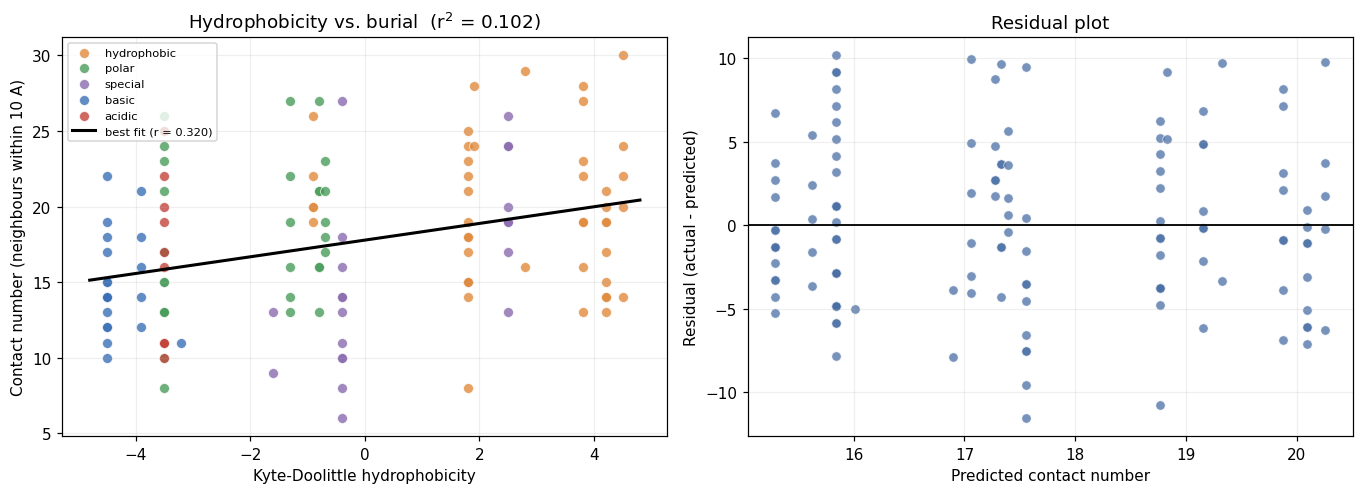

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

# --- Left: the data and the fitted line ---
for cls_name in order:
    sub = mature[mature["class"] == cls_name]
    ax1.scatter(sub["hydrophobicity"], sub["contacts"], c=CLASS_COLORS[cls_name],
                s=42, alpha=0.8, edgecolor="white", linewidth=0.5, label=cls_name)

xs = np.linspace(mature["hydrophobicity"].min() - 0.3, mature["hydrophobicity"].max() + 0.3, 100)
ax1.plot(xs, fit.intercept + fit.slope * xs, color="black", linewidth=2,
         label=f"best fit (r = {fit.rvalue:.3f})")
ax1.set_xlabel("Kyte-Doolittle hydrophobicity")
ax1.set_ylabel(f"Contact number (neighbours within {CONTACT_RADIUS:.0f} A)")
ax1.set_title(f"Hydrophobicity vs. burial  (r$^2$ = {fit.rvalue**2:.3f})")
ax1.legend(fontsize=7.5, loc="upper left")
ax1.grid(alpha=0.2)

# --- Right: residuals, to check whether a straight line was the right model ---
ax2.scatter(predicted, residuals, c="#4A6FA5", s=38, alpha=0.75,
            edgecolor="white", linewidth=0.5)
ax2.axhline(0, color="black", linewidth=1.2)
ax2.set_xlabel("Predicted contact number")
ax2.set_ylabel("Residual (actual - predicted)")
ax2.set_title("Residual plot")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### A real relationship that explains almost nothing

Both of these statements are true at the same time, and holding them together is the whole
skill:

**The relationship is real.** *p* = 2.10 × 10⁻⁴. A correlation this strong would show up by
chance in about 2 samples in 10,000 if hydrophobicity and burial were actually unrelated. The
slope is positive, as chemistry predicts.

**The relationship is weak.** *r²* = 0.102. Hydrophobicity explains **10.2%** of the variation
in burial. The other **89.8%** comes from something else.

Look at the left panel and you can see the 89.8% directly. At any given hydrophobicity there's
a huge vertical spread — residues with the same Kyte–Doolittle value are scattered anywhere
from 8 to 28 neighbours. The fitted line only moves from 15.3 neighbours at the far
hydrophilic end to 20.3 at the far hydrophobic end. That's a 5-neighbour shift across the
entire scale, while individual residues vary by ±5 around the line.

**What's the other 89.8%?** Real, knowable things. Where a residue sits in the chain, whether
it's in a helix or a sheet or a loop, the size of its side chain, whether it's part of the
active site, whether it's locked in a disulfide bridge. A protein's structure is the outcome
of many constraints at once, and side-chain polarity is just one of them.

This is why *r²* deserves to be reported next to every correlation. "Scientists find link
between X and Y" is compatible with a link that explains 3% of anything.

### Checking that a line was the right choice

The right panel is a **residual plot** — for each residue, how far off was our prediction? Two
things to look for:

1. **Are the residuals centered on zero across the whole range?** Ours are. If they curved —
   negative at the ends and positive in the middle, say — it would mean the true relationship
   is curved and a straight line is the wrong model.
2. **Is the spread roughly constant?** Ours is, give or take. If it fanned out, the model
   would be much less reliable at one end than the other.

No obvious pattern here, so a straight line is a defensible summary. Weak, but not wrong.

### And what about confidence?

We have to close the loop on our original question. Same regression, but against pLDDT.

In [22]:
fit_conf = stats.linregress(mature["hydrophobicity"], mature["pLDDT"])

print("Mature enzyme only (residues 19-148)")
print("-" * 52)
print(f"  hydrophobicity vs. burial:  r = {fit.rvalue:+.3f},  r2 = {fit.rvalue**2:.3f},  p = {fit.pvalue:.2e}")
print(f"  hydrophobicity vs. pLDDT :  r = {fit_conf.rvalue:+.3f},  r2 = {fit_conf.rvalue**2:.3f},  p = {fit_conf.pvalue:.4f}")
print()
print(f"  slope: {fit_conf.slope:+.3f} pLDDT points per hydrophobicity unit")
print(f"  across the full -4.5 to +4.5 scale that is a total change of "
      f"{fit_conf.slope*9:.2f} pLDDT points")

Mature enzyme only (residues 19-148)
----------------------------------------------------
  hydrophobicity vs. burial:  r = +0.320,  r2 = 0.102,  p = 2.10e-04
  hydrophobicity vs. pLDDT :  r = +0.180,  r2 = 0.032,  p = 0.0406

  slope: +0.042 pLDDT points per hydrophobicity unit
  across the full -4.5 to +4.5 scale that is a total change of 0.38 pLDDT points


### Technically significant, practically meaningless

*p* = 0.0406 clears the 0.05 bar, so a careless write-up could announce "hydrophobicity
significantly predicts AlphaFold confidence." Look at what that actually amounts to:

*r²* = 0.032 — **3.2%** of the variation. And the slope says that going all the way from the
most water-loving residue to the most water-repelling one moves the predicted confidence by
**0.38 pLDDT points**. On a 100-point scale. For a protein where every residue already scores
between 95 and 99.

This is the clearest illustration in the notebook of why *p* < 0.05 is not the finish line.
With a big enough sample, a trivially small effect will clear it. **Significance tells you an
effect probably isn't zero. Effect size tells you whether anyone should care.** Report both,
always.

So our final answer is:

- Chemistry → **burial**: real, modest, well-supported.
- Chemistry → **AlphaFold's confidence**: technically detectable, far too small to matter.

Which is a perfectly good place to stop.

Except there's one loose end. Remember what we set aside in section 3.

---

# 9. Wait — is something else causing this?

Back in section 3 we made a deliberate choice: study the **mature enzyme**, residues 19–148,
and set the signal peptide aside.

That was a defensible scientific decision, made for a stated reason, before we looked at any
results. But every such decision is a fork in the road, and we owe it to ourselves to find out
what was down the other path.

So let's redo the exact same analysis on the **full 148-residue chain** and compare.

In [23]:
lyso_fit = stats.linregress(lyso["hydrophobicity"], lyso["pLDDT"])

full_hydrophobic = lyso.loc[lyso["class"] == "hydrophobic", "pLDDT"]
full_charged = lyso.loc[lyso["class"].isin(["acidic", "basic"]), "pLDDT"]
t_full, p_full = stats.ttest_ind(full_hydrophobic, full_charged, equal_var=False)

comparison = pd.DataFrame([
    {"analysis": "Mature enzyme (19-148)", "n": len(mature),
     "mean_pLDDT_hydrophobic": round(hydrophobic.mean(), 2),
     "mean_pLDDT_charged": round(charged.mean(), 2),
     "difference": round(hydrophobic.mean() - charged.mean(), 2),
     "t_test_p": round(p_value, 4),
     "r(hydrophobicity, pLDDT)": round(fit_conf.rvalue, 3)},
    {"analysis": "Full chain (1-148)", "n": len(lyso),
     "mean_pLDDT_hydrophobic": round(full_hydrophobic.mean(), 2),
     "mean_pLDDT_charged": round(full_charged.mean(), 2),
     "difference": round(full_hydrophobic.mean() - full_charged.mean(), 2),
     "t_test_p": round(p_full, 4),
     "r(hydrophobicity, pLDDT)": round(lyso_fit.rvalue, 3)},
])

print("THE SAME QUESTION, ASKED OF THE SAME PROTEIN, TWO WAYS")
print("=" * 78)
print(comparison.to_string(index=False))
print()
print(f"Mature enzyme: hydrophobic residues score {hydrophobic.mean() - charged.mean():+.2f} "
      f"pLDDT vs charged  (p = {p_value:.4f})")
print(f"Full chain:    hydrophobic residues score {full_hydrophobic.mean() - full_charged.mean():+.2f} "
      f"pLDDT vs charged  (p = {p_full:.4f})")
print()
print(f"Correlation flips sign:  r = {fit_conf.rvalue:+.3f}  ->  r = {lyso_fit.rvalue:+.3f}")

THE SAME QUESTION, ASKED OF THE SAME PROTEIN, TWO WAYS
              analysis   n  mean_pLDDT_hydrophobic  mean_pLDDT_charged  difference  t_test_p  r(hydrophobicity, pLDDT)
Mature enzyme (19-148) 130                   98.56               98.22        0.34    0.0794                     0.180
    Full chain (1-148) 148                   90.42               96.56       -6.13    0.0260                    -0.251

Mature enzyme: hydrophobic residues score +0.34 pLDDT vs charged  (p = 0.0794)
Full chain:    hydrophobic residues score -6.13 pLDDT vs charged  (p = 0.0260)

Correlation flips sign:  r = +0.180  ->  r = -0.251


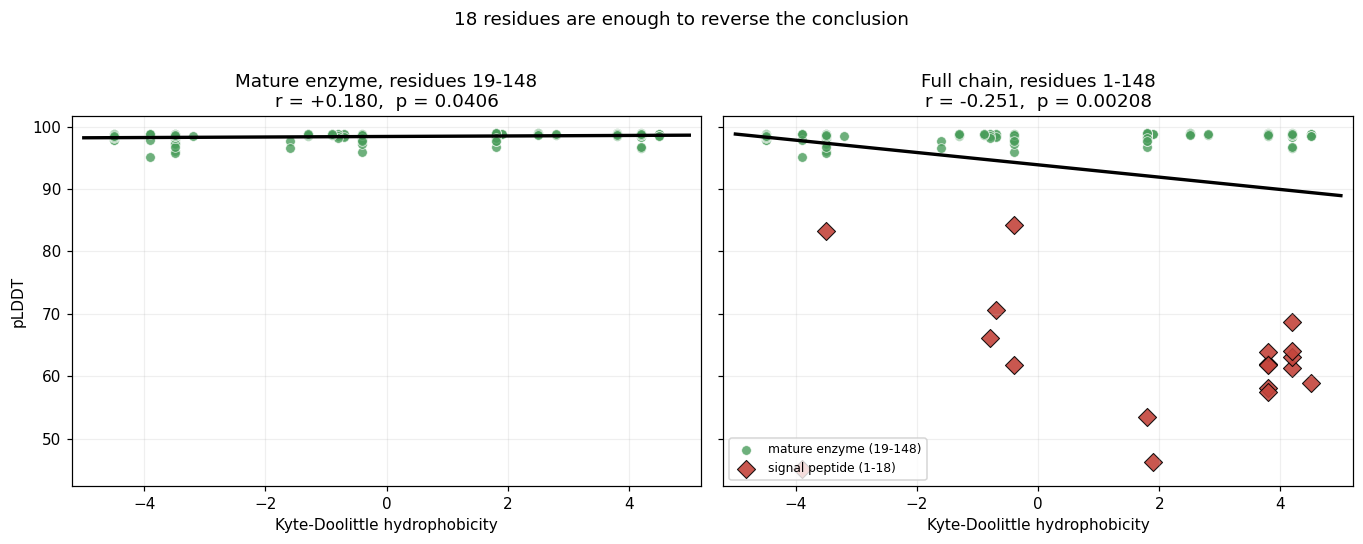

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)

xs = np.linspace(-5, 5, 100)

# --- Left: mature enzyme only ---
ax1.scatter(mature["hydrophobicity"], mature["pLDDT"], c="#4A9D5B", s=40,
            alpha=0.8, edgecolor="white", linewidth=0.5)
ax1.plot(xs, fit_conf.intercept + fit_conf.slope * xs, color="black", linewidth=2.2)
ax1.set_title(f"Mature enzyme, residues 19-148\nr = {fit_conf.rvalue:+.3f},  p = {fit_conf.pvalue:.4f}")
ax1.set_xlabel("Kyte-Doolittle hydrophobicity")
ax1.set_ylabel("pLDDT")

# --- Right: the full chain, signal peptide included ---
is_signal = lyso["position"] <= SIGNAL_PEPTIDE_END
ax2.scatter(lyso.loc[~is_signal, "hydrophobicity"], lyso.loc[~is_signal, "pLDDT"],
            c="#4A9D5B", s=40, alpha=0.8, edgecolor="white", linewidth=0.5,
            label="mature enzyme (19-148)")
ax2.scatter(lyso.loc[is_signal, "hydrophobicity"], lyso.loc[is_signal, "pLDDT"],
            c="#C4453C", s=70, alpha=0.9, edgecolor="black", linewidth=0.7,
            marker="D", label="signal peptide (1-18)")
ax2.plot(xs, lyso_fit.intercept + lyso_fit.slope * xs, color="black", linewidth=2.2)
ax2.set_title(f"Full chain, residues 1-148\nr = {lyso_fit.rvalue:+.3f},  p = {lyso_fit.pvalue:.5f}")
ax2.set_xlabel("Kyte-Doolittle hydrophobicity")
ax2.legend(fontsize=8, loc="lower left")

for ax in (ax1, ax2):
    ax.grid(alpha=0.2)
    ax.set_xlim(-5.2, 5.2)

fig.suptitle("18 residues are enough to reverse the conclusion", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Look at what just happened

| | Mature enzyme (19–148) | Full chain (1–148) |
|---|---|---|
| Hydrophobic vs. charged | **+0.34** pLDDT | **−6.13** pLDDT |
| *t*-test | *p* = 0.0794 | *p* = 0.0260 |
| Correlation *r* | **+0.180** | **−0.251** |
| *p* for the correlation | 0.0406 | 0.00208 |

Same protein. Same data file. Same code. **Opposite conclusions — and both of the full-chain
results are statistically significant.**

If you had analyzed the full chain, you'd have published: *"hydrophobic residues are
significantly HARDER for AlphaFold to model (p = 0.026)."* If you analyzed the mature enzyme,
you'd have published: *"hydrophobic residues are significantly EASIER to model (p = 0.041)."*
Both writers did honest arithmetic. At most one of them is right.

### The culprit is a third variable

Look at the red diamonds in the right panel. Almost every signal-peptide residue sits low on
the plot, and most of them sit low **and** far to the right: **high hydrophobicity, low
pLDDT**. Eighteen points, all pulling down on the right-hand side, are enough by themselves to
tip the fitted line from sloping upward to sloping downward.

Why are they there? Because of something that has nothing to do with our hypothesis:

- The signal peptide is **unusually hydrophobic** — mean Kyte–Doolittle of **+1.91**, against
  **−0.49** for the rest of the protein. That's not random. A signal peptide's job is to be
  recognized by, and thread through, the greasy interior of a membrane, so evolution made it
  greasy. 12 of its 18 residues are in our hydrophobic class.
- The signal peptide is also **unstructured on its own**, so its mean pLDDT is **62.8** versus
  98.4 for the mature enzyme.

One hidden variable — *is this residue part of a folded domain?* — independently drives both
of the things we were correlating. It makes hydrophobicity go up and it makes pLDDT go down,
which manufactures a negative correlation between them out of nothing.

That hidden variable has a name: a **confounding variable**. When mixing two groups reverses
the direction of an effect like this, statisticians call it **Simpson's paradox**. It is not a
rare curiosity — it is one of the most common ways real analyses go wrong.

### Why "just use all the data" is not the answer

The instinct after seeing this is usually: *don't throw data away, analyze everything.* But the
full-chain analysis is the one that's **misleading**, and it used all the data.

The problem was never the sample size. It was asking one question of two populations at once.
The mature enzyme and the signal peptide are different kinds of thing — one is a folded
globule, the other is a floppy targeting tag that gets cut off and destroyed. Averaging across
them answers a question nobody asked.

**The defense isn't more data. It's defining your population before you analyze it, for a
stated biological reason, and then reporting what happens if you'd chosen differently.**
Which is exactly what we just did, and it's why we caught this instead of publishing it.

Fetching human p53 (UniProt P04637):
  p53_entry.json                   (cache, 19 KB)
  p53_plddt.json                   (cache, 5 KB)

                      pLDDT       hydrophobicity      
                       mean count           mean count
region                                                
folded core (94-312)  90.84   219          -0.64   219
the rest              55.17   174          -0.91   174



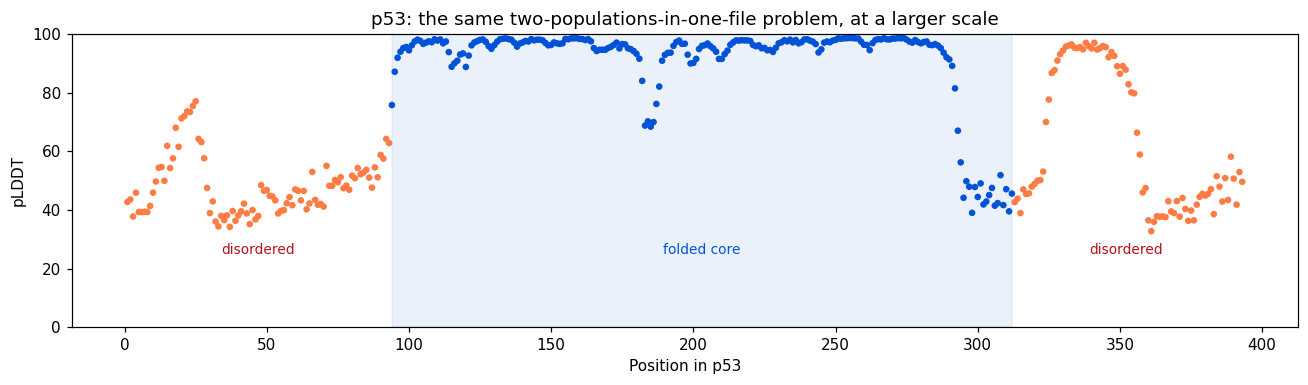

In [25]:
# Does the same trap appear in a bigger protein? p53 is a good test case:
# it has both a rigidly folded core and long disordered regions.
print("Fetching human p53 (UniProt P04637):")
p53_entry = fetch_cached("https://alphafold.ebi.ac.uk/api/prediction/P04637", "p53_entry.json")[0]
p53_plddt = fetch_cached(p53_entry["plddtDocUrl"], "p53_plddt.json")

p53 = pd.DataFrame({
    "position": np.arange(1, len(p53_entry["sequence"]) + 1),
    "aa": list(p53_entry["sequence"]),
    "pLDDT": np.array(p53_plddt["confidenceScore"]),
}).merge(aa_table, on="aa", how="left")

# p53's DNA-binding domain (residues 94-312) is its well-folded core
p53["region"] = np.where(p53["position"].between(94, 312), "folded core (94-312)", "the rest")

print()
print(p53.groupby("region")[["pLDDT", "hydrophobicity"]].agg(["mean", "count"]).round(2).to_string())
print()

fig, ax = plt.subplots(figsize=(12, 3.6))
colors_by_region = np.where(p53["region"] == "folded core (94-312)", "#0053D6", "#FF7D45")
ax.scatter(p53["position"], p53["pLDDT"], c=colors_by_region, s=11)
ax.axvspan(94, 312, color="#0053D6", alpha=0.08)
ax.text(203, 25, "folded core", ha="center", fontsize=9, color="#0053D6")
ax.text(47, 25, "disordered", ha="center", fontsize=9, color="#B5121B")
ax.text(352, 25, "disordered", ha="center", fontsize=9, color="#B5121B")
ax.set_xlabel("Position in p53")
ax.set_ylabel("pLDDT")
ax.set_title("p53: the same two-populations-in-one-file problem, at a larger scale")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

### The same trap, one protein bigger

p53 is a tumour suppressor — the single most frequently mutated gene in human cancer. Its
folded DNA-binding core averages **pLDDT 90.8**. Everything outside that core averages
**55.2**, because those regions are *intrinsically disordered*: they genuinely have no fixed
shape until they bind a partner.

So a single p53 data file contains two populations that differ by 35 pLDDT points, for reasons
that have nothing to do with side-chain chemistry. Any correlation you compute across the
whole protein is dominated by which region a residue happens to fall in — exactly the lysozyme
problem, at four times the scale.

And notice this is not a rare edge case we hunted for. It's a signal peptide in the first
protein we picked, and disorder in the second. Roughly a third of human proteins contain
substantial disordered regions. **Proteins that are one uniform population are the exception.**

The habit that protects you is not a statistical test. It's asking, before you compute
anything: *are all of these rows really the same kind of thing?*

---

# 10. What did we actually learn?

We started with a single question: **does a residue's side-chain chemistry explain how
confidently AlphaFold models it?**

Nine sections later we have an answer, and it is not the one the question was fishing for.
Let's put every number we computed in one place before we interpret anything.


In [26]:
# Every test in this notebook, assembled from the variables we computed along the way.
# Nothing here is retyped by hand - if an upstream number changed, this table changes with it.

def eta_squared(groups):
    """Fraction of total variation explained by group membership (the ANOVA effect size)."""
    all_vals = np.concatenate(groups)
    grand_mean = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((all_vals - grand_mean) ** 2).sum()
    return ss_between / ss_total

eta2_conf = eta_squared([mature.loc[mature["class"] == c, "pLDDT"].values for c in order])
eta2_burial = eta_squared([mature.loc[mature["class"] == c, "contacts"].values for c in order])

results = pd.DataFrame([
    {"section": 4, "question": "Do hydrophobic residues score higher than charged ones?",
     "test": "Welch t-test", "statistic": f"t = {t_stat:.2f}", "p": p_value,
     "effect size": f"d = {cohens_d:.2f}", "verdict": "not significant"},
    {"section": 5, "question": "Do any of the five classes differ in pLDDT?",
     "test": "one-way ANOVA", "statistic": f"F = {f_stat:.2f}", "p": p_anova,
     "effect size": f"eta2 = {eta2_conf:.3f}", "verdict": "not significant"},
    {"section": 7, "question": "Do the five classes differ in burial?",
     "test": "one-way ANOVA", "statistic": f"F = {f_burial:.2f}", "p": p_burial,
     "effect size": f"eta2 = {eta2_burial:.3f}", "verdict": "SIGNIFICANT"},
    {"section": 7, "question": "Are hydrophobic residues over-represented in the buried half?",
     "test": "chi-square", "statistic": f"X2 = {chi2:.2f}", "p": p_chi,
     "effect size": f"OR = {odds_ratio:.2f}", "verdict": "SIGNIFICANT"},
    {"section": 8, "question": "Does hydrophobicity predict burial?",
     "test": "linear regression", "statistic": f"r = {fit.rvalue:+.3f}", "p": fit.pvalue,
     "effect size": f"r2 = {fit.rvalue**2:.3f}", "verdict": "SIGNIFICANT"},
    {"section": 8, "question": "Does hydrophobicity predict pLDDT?",
     "test": "linear regression", "statistic": f"r = {fit_conf.rvalue:+.3f}", "p": fit_conf.pvalue,
     "effect size": f"r2 = {fit_conf.rvalue**2:.3f}", "verdict": "significant but tiny"},
    {"section": 9, "question": "Same question, full chain including signal peptide",
     "test": "linear regression", "statistic": f"r = {lyso_fit.rvalue:+.3f}", "p": lyso_fit.pvalue,
     "effect size": f"r2 = {lyso_fit.rvalue**2:.3f}", "verdict": "SIGNIFICANT, opposite sign"},
])
results["p"] = results["p"].map(lambda v: f"{v:.4f}" if v >= 1e-4 else f"{v:.1e}")

print("EVERY TEST IN THIS NOTEBOOK")
print("=" * 118)
print(results.to_string(index=False))
print()
print(f"All tests above use the mature enzyme (n = {len(mature)} residues) unless noted otherwise.")


EVERY TEST IN THIS NOTEBOOK
 section                                                      question              test  statistic      p  effect size                    verdict
       4       Do hydrophobic residues score higher than charged ones?      Welch t-test   t = 1.79 0.0794     d = 0.46            not significant
       5                   Do any of the five classes differ in pLDDT?     one-way ANOVA   F = 1.79 0.1359 eta2 = 0.054            not significant
       7                         Do the five classes differ in burial?     one-way ANOVA   F = 4.60 0.0017 eta2 = 0.128                SIGNIFICANT
       7 Are hydrophobic residues over-represented in the buried half?        chi-square  X2 = 8.80 0.0030    OR = 3.31                SIGNIFICANT
       8                           Does hydrophobicity predict burial? linear regression r = +0.320 0.0002   r2 = 0.102                SIGNIFICANT
       8                            Does hydrophobicity predict pLDDT? linear regression r

### The table tells a three-part story

**Part one: our original hypothesis is dead.** Sections 4 and 5 asked directly whether
side-chain class predicts AlphaFold's confidence, and the answer was no both times — *p* = 0.079
for the *t*-test, *p* = 0.136 for the ANOVA. Chemistry class explains **η² = 0.054**, about 5%,
of the variation in pLDDT, and that much could easily be noise in a sample of 130.

**Part two: the same chemistry predicts something else beautifully.** Every test involving
*burial* came back significant, and not marginally: *p* = 0.0017, *p* = 0.0030, *p* = 0.00021.
Hydrophobic residues are 3.3× more likely to sit in the buried half of the protein. That is the
hydrophobic effect — the actual physical force that folds proteins — showing up in coordinates
downloaded from a website.

**Part three: the two facts are not in tension, and understanding why is the point.** Chemistry
really does drive burial, and burial really is part of what makes a structure well-determined.
So why doesn't the chain carry through to pLDDT?

Because in lysozyme there's no room left for it to. **Every mature residue already scores
between 95 and 99.** Lysozyme is small, rigid, disulfide-locked, and has been crystallized
hundreds of times. AlphaFold is maximally confident about all of it. You cannot detect a
predictor of a quantity that doesn't vary — and this is a general principle, not a quirk of our
data. **No variance in the outcome, no correlation to find, no matter how real the underlying
mechanism is.**

Section 9 showed the flip side. The moment we added 18 residues that *weren't* part of the
folded enzyme, pLDDT started varying — by 36 points — and a correlation appeared instantly. It
just wasn't the correlation we were looking for.


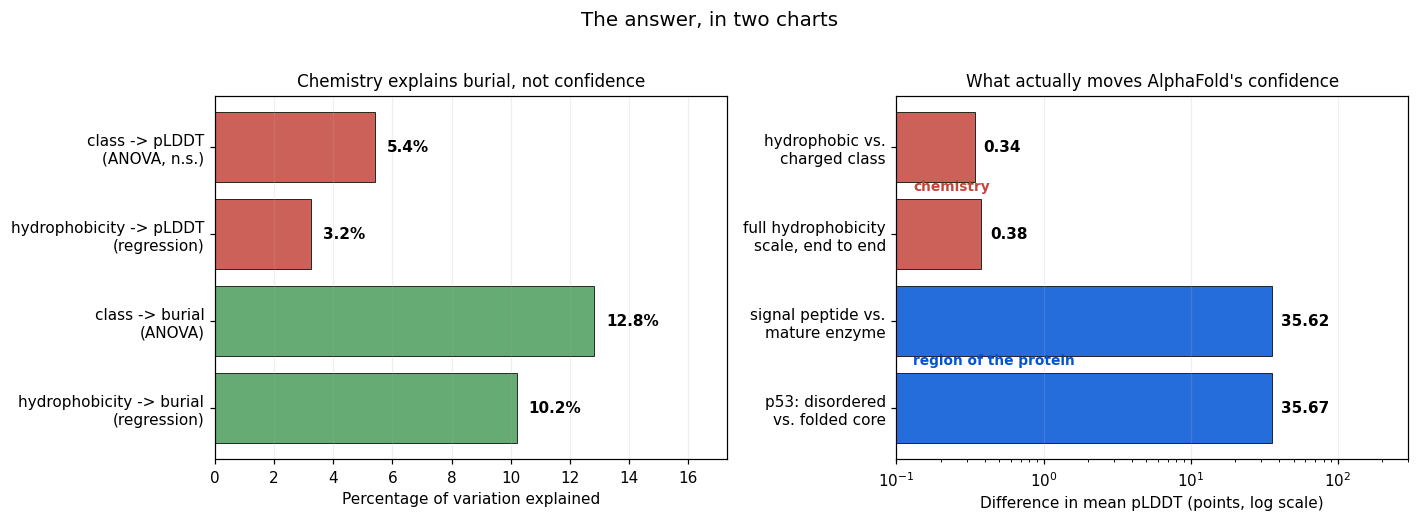

Chemistry moves pLDDT by 0.38 points across its entire range.
Being in a disordered region instead of a folded one moves it by 35.7 points - roughly 95x more.


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Left: how much variation does chemistry explain? ---
labels = ["class -> pLDDT\n(ANOVA, n.s.)",
          "hydrophobicity -> pLDDT\n(regression)",
          "class -> burial\n(ANOVA)",
          "hydrophobicity -> burial\n(regression)"]
values = [100 * eta2_conf, 100 * fit_conf.rvalue**2, 100 * eta2_burial, 100 * fit.rvalue**2]
colors = ["#C4453C", "#C4453C", "#4A9D5B", "#4A9D5B"]

bars = ax1.barh(labels, values, color=colors, alpha=0.85, edgecolor="black", linewidth=0.6)
for bar, v in zip(bars, values):
    ax1.text(v + 0.4, bar.get_y() + bar.get_height() / 2, f"{v:.1f}%",
             va="center", fontsize=10, fontweight="bold")
ax1.set_xlabel("Percentage of variation explained")
ax1.set_title("Chemistry explains burial, not confidence", fontsize=11)
ax1.set_xlim(0, max(values) * 1.35)
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.2)

# --- Right: how big is each effect, measured in actual pLDDT points? ---
effect_labels = ["hydrophobic vs.\ncharged class",
                 "full hydrophobicity\nscale, end to end",
                 "signal peptide vs.\nmature enzyme",
                 "p53: disordered\nvs. folded core"]
p53_gap = (p53.loc[p53["region"] == "folded core (94-312)", "pLDDT"].mean() -
           p53.loc[p53["region"] == "the rest", "pLDDT"].mean())
signal_gap = (mature["pLDDT"].mean() -
              lyso.loc[lyso["position"] <= SIGNAL_PEPTIDE_END, "pLDDT"].mean())
effect_values = [abs(hydrophobic.mean() - charged.mean()), abs(fit_conf.slope * 9),
                 signal_gap, p53_gap]
effect_colors = ["#C4453C", "#C4453C", "#0053D6", "#0053D6"]

bars2 = ax2.barh(effect_labels, effect_values, color=effect_colors, alpha=0.85,
                 edgecolor="black", linewidth=0.6)
for bar, v in zip(bars2, effect_values):
    ax2.text(v * 1.15, bar.get_y() + bar.get_height() / 2, f"{v:.2f}",
             va="center", fontsize=10, fontweight="bold")
ax2.set_xscale("log")
ax2.set_xlim(0.1, 300)
ax2.set_xlabel("Difference in mean pLDDT (points, log scale)")
ax2.set_title("What actually moves AlphaFold's confidence", fontsize=11)
ax2.invert_yaxis()
ax2.grid(axis="x", alpha=0.2)
ax2.annotate("chemistry", xy=(0.13, 0.5), fontsize=9, color="#C4453C", fontweight="bold")
ax2.annotate("region of the protein", xy=(0.13, 2.5), fontsize=9, color="#0053D6",
             fontweight="bold")

fig.suptitle("The answer, in two charts", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Chemistry moves pLDDT by {abs(fit_conf.slope * 9):.2f} points across its entire range.")
print(f"Being in a disordered region instead of a folded one moves it by {p53_gap:.1f} points "
      f"- roughly {p53_gap / abs(fit_conf.slope * 9):.0f}x more.")


### The honest answer to our question

> **Does a residue's chemistry explain how confident AlphaFold is?**
>
> Barely. Chemistry has a real, strong effect on where a residue sits in the fold, and only a
> negligible effect on AlphaFold's confidence. What *dominates* confidence is something much
> coarser: **whether the residue belongs to a region that has a fixed shape at all.** Chemistry
> determines the fold's interior; being part of a fold at all determines pLDDT.

Which raises a nice question to sit with: pLDDT was never designed to measure chemistry. It
estimates *how close this prediction is likely to be to the truth*. Disordered regions have no
single truth to be close to, so they score low — correctly. A low pLDDT is not AlphaFold
failing. It is AlphaFold telling you something true about the protein.

---

## What this notebook can't tell you

Every result above is bounded by choices we made. Stating them isn't modesty — it's the part
that lets someone else check your work.

**1. It's one protein — and an unusually easy one.** Human lysozyme is 148 residues, rigidly
folded, held by four disulfide bonds, and represented in the PDB hundreds of times over. Nothing
here establishes that these numbers hold for membrane proteins, large multi-domain proteins, or
anything AlphaFold finds hard. The p53 comparison in section 9 is a second data point, not a
survey. A real version of this study would sample hundreds of proteins across structural
classes.

**2. AlphaFold has seen lysozyme.** It was trained on the PDB, which contains many lysozyme
structures. Its confidence here partly reflects *familiarity with this exact protein*, not just
inference from sequence. That's a mild form of circularity, and it's one more reason the pLDDT
ceiling is so high.

**3. "Contact number within 10 Å" is a proxy, not a measurement.** Structural biologists measure
burial with **relative solvent accessible surface area** (RSA), which accounts for side-chain
size and geometry. Contact number is easy to compute from coordinates and correlates with RSA,
but a large exposed residue and a small buried one can end up with similar counts. The 10 Å
cutoff was chosen before we looked at results — but it was still chosen.

**4. Five chemical classes is a coarse grouping.** Grouping 20 amino acids into five buckets
throws away real distinctions: tryptophan and alanine are both "hydrophobic" while differing
threefold in size. Kyte–Doolittle is likewise only one of several published hydrophobicity
scales, and they disagree with each other. Different reasonable choices would give somewhat
different numbers.

**5. We ran seven tests and reported all seven — but seven is enough to need care.** At α = 0.05,
running many tests on the same data inflates the chance that at least one comes back
"significant" by luck. We didn't apply a correction (Bonferroni would use 0.05/7 ≈ 0.007 here),
which would strip section 8's *p* = 0.041 pLDDT result of its significance. Since we already
concluded that effect was too small to care about, nothing downstream changes — but a study
whose headline result sat at *p* = 0.04 after seven tests would be on thin ice.

**6. Nothing here is causal.** We measured associations in observational data. We have a strong
mechanistic reason to believe hydrophobicity *causes* burial — that's textbook thermodynamics —
but the statistics alone can't establish it. Section 9 is a demonstration of exactly how badly
that inference can go wrong when a hidden variable is doing the work.

**7. pLDDT is a model's self-assessment.** It is AlphaFold's own estimate of its accuracy, not
an independent measurement. It's well-calibrated in benchmarks, but analyzing it tells you about
*AlphaFold's* behavior, which is not the same thing as telling you about proteins.

---

## Where you could take this next

Each of these is a real project, and each one directly attacks a limitation above:

- **Break the ceiling.** Rerun sections 4–8 on a protein whose pLDDT actually varies — p53 is
  already loaded and cached. Does chemistry predict confidence *within* the folded core alone?
  That's the clean test lysozyme couldn't give us.
- **Scale up.** The AlphaFold API takes any UniProt accession. Pull 100 proteins, compute the
  chemistry–burial correlation in each, and plot the distribution of *r* values. One *r* is an
  anecdote; a distribution of 100 is evidence.
- **Fix the proxy.** Use Biopython's `ShrakeRupley` module to compute real solvent accessibility
  and redo section 7. Does the odds ratio get stronger, as it should if contact number was
  adding noise?
- **Add the missing variable.** Section 8 left 89.8% of burial unexplained. Add secondary
  structure (helix / sheet / loop) and side-chain volume as predictors in a multiple regression
  and see how much of that gap closes.

---

## The one thing worth remembering

We set out to confirm a hypothesis and failed to confirm it. Then, following the data instead of
the hypothesis, we found a stronger and more interesting result we hadn't been looking for — and
then nearly convinced ourselves of the exact opposite conclusion by including 18 extra rows.

That sequence — **fail, follow, nearly fool yourself, check** — isn't a sign the investigation
went badly. It's what the process looks like when it's working. The tools that saved us were not
sophisticated: report the effect size next to the *p*-value, define your population before you
analyze it, and ask whether all your rows are really the same kind of thing.

Real data downloaded from a real database, analyzed honestly, will teach you something you
didn't set out to learn. That's the whole reason to use real data.
